In [62]:
#Se importan las librerias a utilizar

import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
%matplotlib inline

In [63]:
#Cargamos los datos ya con las variables definitivas para el Modelo sin Geo y con las variables Categóricas ya convertidas a Dummies
import chardet
with open("CasasEnVenta_Madrid_KDD.csv", "rb") as f:
    result = chardet.detect(f.read())
    encoding_detected = result["encoding"]

datos_def = pd.read_csv("CasasEnVenta_Madrid_KDD.csv", encoding=encoding_detected, sep=';', index_col='id')
print(datos_def.head(5))

     precio  metros_cuadrados_utiles  numero_baNos  numero_habitaciones  \
id                                                                        
1    650000                       78             1                    2   
2    525000                       62             1                    1   
3    795000                      113             2                    5   
4   3650000                      290             5                    4   
5   5100000                      270             5                    4   

    planta  antigUedad  aire_acondicionado_Si  ascensor_Si  piscina_Si  \
id                                                                       
1        2          66                  False         True       False   
2        4          57                  False         True       False   
3        4          54                  False         True       False   
4        5          85                   True         True       False   
5        6          59        

**- Análisis completo del Data y Variables definitivas.**
-seleccion de variables definitivas.

In [64]:
datos_def.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16923 entries, 1 to 19444
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   precio                   16923 non-null  int64
 1   metros_cuadrados_utiles  16923 non-null  int64
 2   numero_baNos             16923 non-null  int64
 3   numero_habitaciones      16923 non-null  int64
 4   planta                   16923 non-null  int64
 5   antigUedad               16923 non-null  int64
 6   aire_acondicionado_Si    16923 non-null  bool 
 7   ascensor_Si              16923 non-null  bool 
 8   piscina_Si               16923 non-null  bool 
 9   trastero_Si              16923 non-null  bool 
 10  garaje_Si                16923 non-null  bool 
 11  balcon_Si                16923 non-null  bool 
 12  jardin_Si                16923 non-null  bool 
 13  armarios_Si              16923 non-null  bool 
dtypes: bool(8), int64(6)
memory usage: 1.0 MB


In [65]:
# Veamos el número de nulos de cada variable
datos_def.isnull().sum()

precio                     0
metros_cuadrados_utiles    0
numero_baNos               0
numero_habitaciones        0
planta                     0
antigUedad                 0
aire_acondicionado_Si      0
ascensor_Si                0
piscina_Si                 0
trastero_Si                0
garaje_Si                  0
balcon_Si                  0
jardin_Si                  0
armarios_Si                0
dtype: int64

In [66]:
# Con el siguiente gráfico podemos entender cada característica numérica analizando la media (mean), la desviación estándar (std)
# el valor míninimo, el valor máximo y el valor de los cuartiles (25%, 50% y 75%)
# Comentar datos definitivos

datos_def.describe().T

,count,mean,std,min,25%,50%,75%,max
precio,16923.0,830968.857708,853197.316762,35000.0,270000.0,495000.0,1100000.0,5400000.0
metros_cuadrados_utiles,16923.0,169.763872,143.624298,40.0,78.0,119.0,210.0,1000.0
numero_baNos,16923.0,2.380724,1.375620,1.0,1.0,2.0,3.0,10.0
numero_habitaciones,16923.0,3.223719,1.498906,0.0,2.0,3.0,4.0,20.0
planta,16923.0,1.992968,1.972212,0.0,0.0,1.0,3.0,10.0
antigUedad,16923.0,44.046268,31.092339,0.0,21.0,41.0,61.0,225.0


array([[<Axes: title={'center': 'precio'}>,
        <Axes: title={'center': 'metros_cuadrados_utiles'}>],
       [<Axes: title={'center': 'numero_baNos'}>,
        <Axes: title={'center': 'numero_habitaciones'}>],
       [<Axes: title={'center': 'planta'}>,
        <Axes: title={'center': 'antigUedad'}>]], dtype=object)

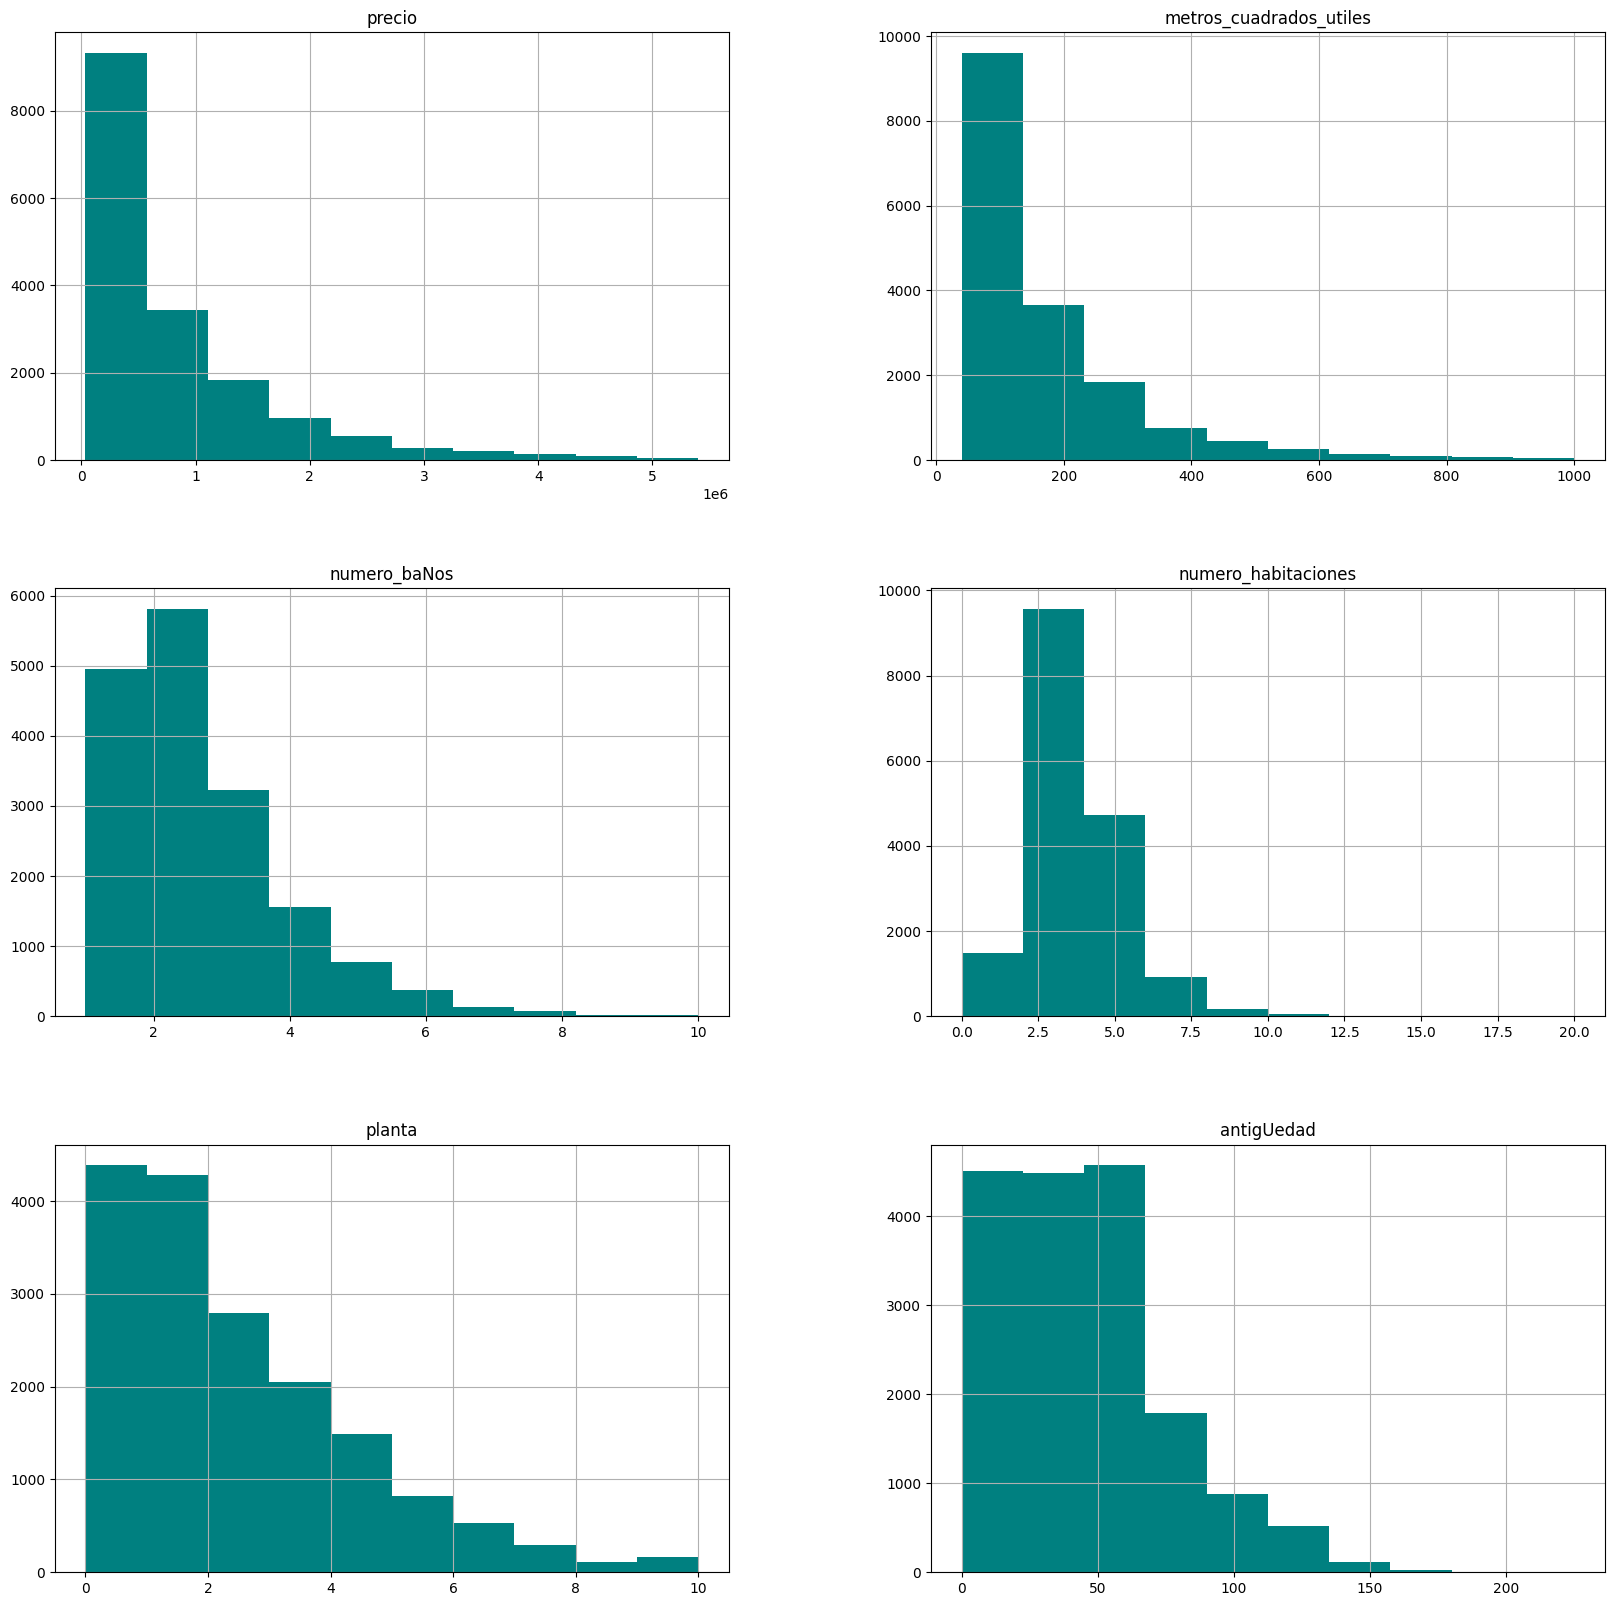

In [67]:
# Pintamos el histograma de cada variable por si se escapa algun outlier
datos_def.hist(figsize = (20,20), color="#008080")

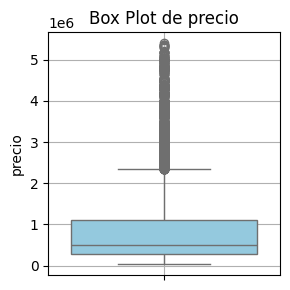

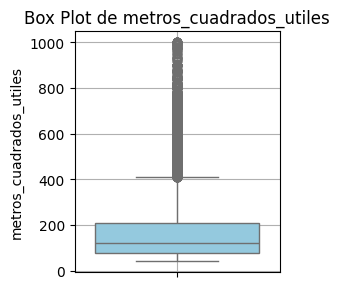

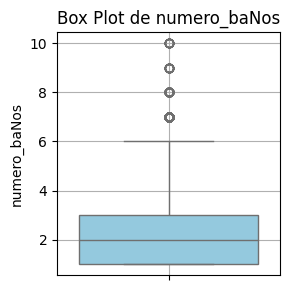

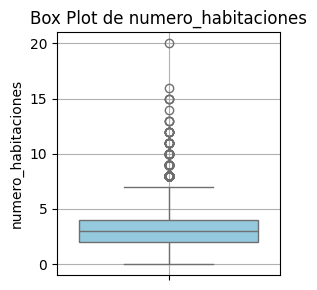

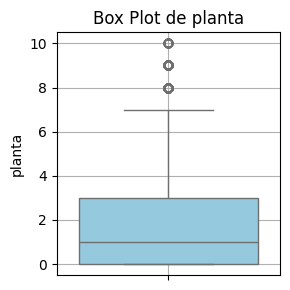

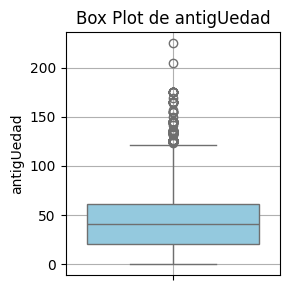

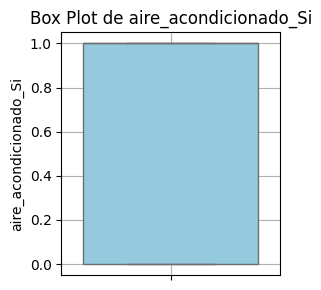

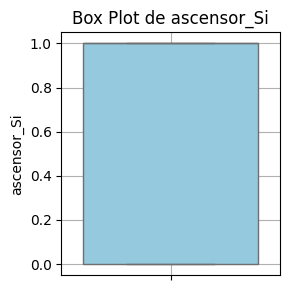

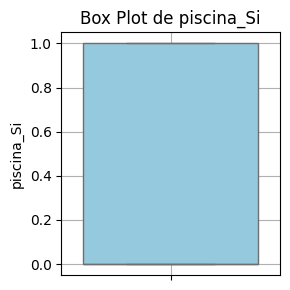

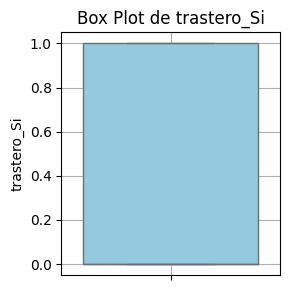

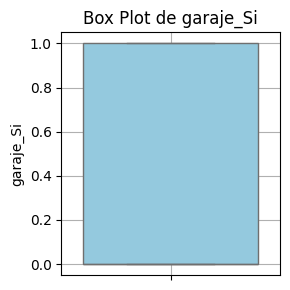

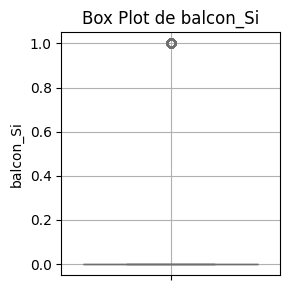

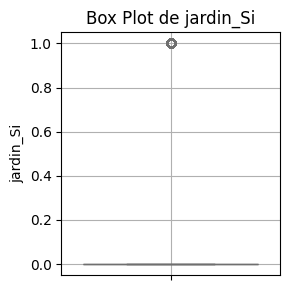

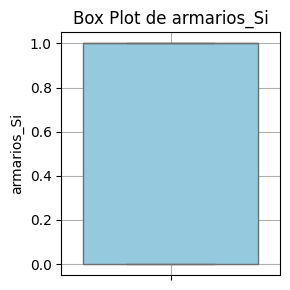

In [68]:
# Veamos ahora los diagramas de bigotes para cada variable.
# Pintamos el diagrama de bigotes de cada variable por si se escapa algun outlier
for var in datos_def.columns:
    plt.figure(figsize=(3, 3))
    sns.boxplot(y=var, data=datos_def, color='skyblue')
    plt.title(f'Box Plot de {var}')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [69]:
# Veamos la correlación entre todas las variables. 
correlations = datos_def.corr()
print(correlations)

                           precio  metros_cuadrados_utiles  numero_baNos  \
precio                   1.000000                 0.556015      0.613824   
metros_cuadrados_utiles  0.556015                 1.000000      0.797879   
numero_baNos             0.613824                 0.797879      1.000000   
numero_habitaciones      0.342469                 0.703889      0.692212   
planta                   0.163988                -0.178120     -0.105788   
antigUedad               0.178632                -0.149159     -0.129487   
aire_acondicionado_Si    0.229383                 0.065024      0.157596   
ascensor_Si              0.178535                -0.322013     -0.189846   
piscina_Si               0.067862                 0.372722      0.353826   
trastero_Si              0.126275                 0.285971      0.291184   
garaje_Si                0.115029                 0.350809      0.365361   
balcon_Si                0.144658                 0.140751      0.162856   
jardin_Si   

In [70]:
print(correlations["precio"])


precio                     1.000000
metros_cuadrados_utiles    0.556015
numero_baNos               0.613824
numero_habitaciones        0.342469
planta                     0.163988
antigUedad                 0.178632
aire_acondicionado_Si      0.229383
ascensor_Si                0.178535
piscina_Si                 0.067862
trastero_Si                0.126275
garaje_Si                  0.115029
balcon_Si                  0.144658
jardin_Si                  0.074497
armarios_Si                0.135491
Name: precio, dtype: float64


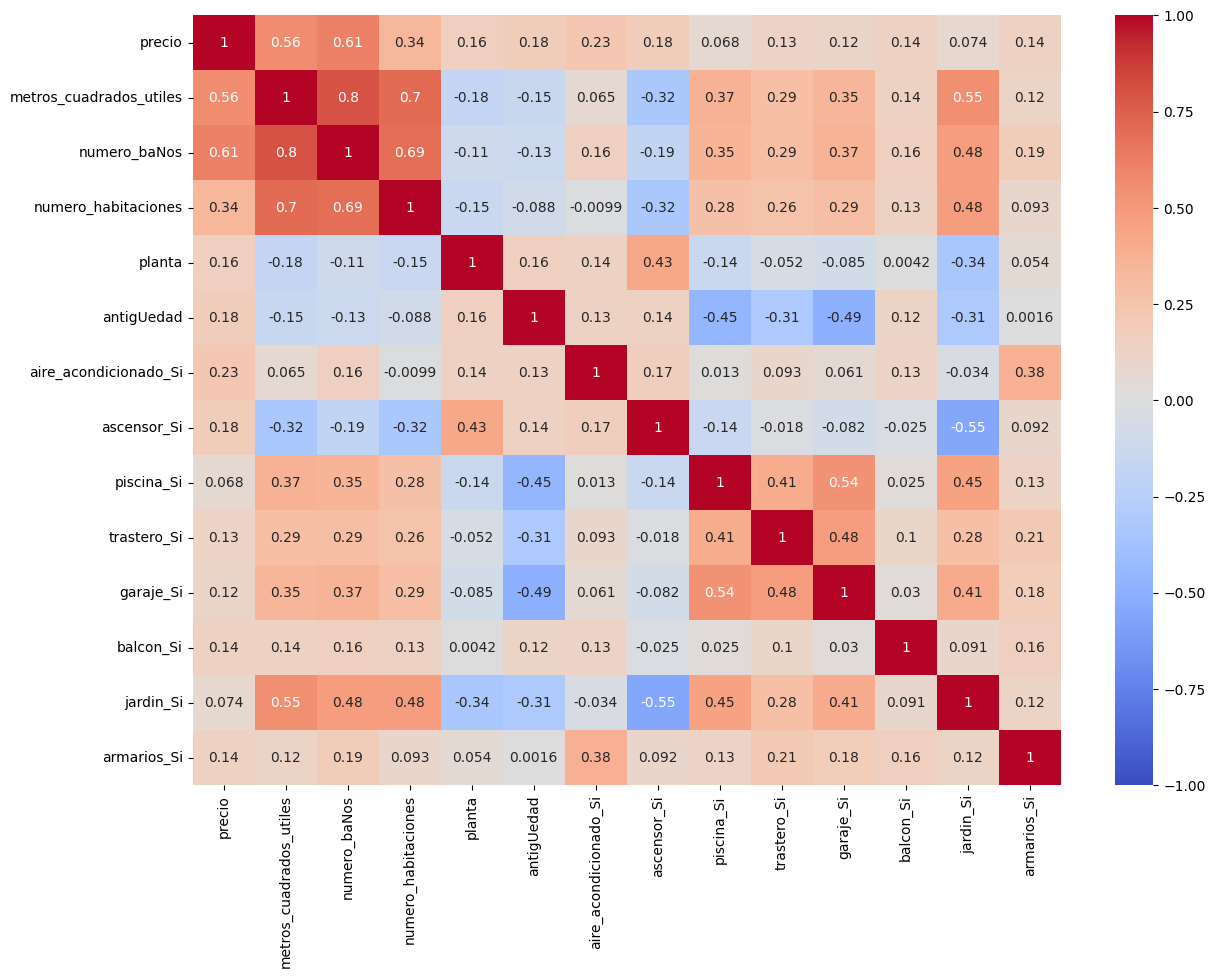

In [71]:
# Gráfico con la matriz de correlación entre todas las variables.
plt.figure(figsize=(14,10))
sns.heatmap(correlations, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

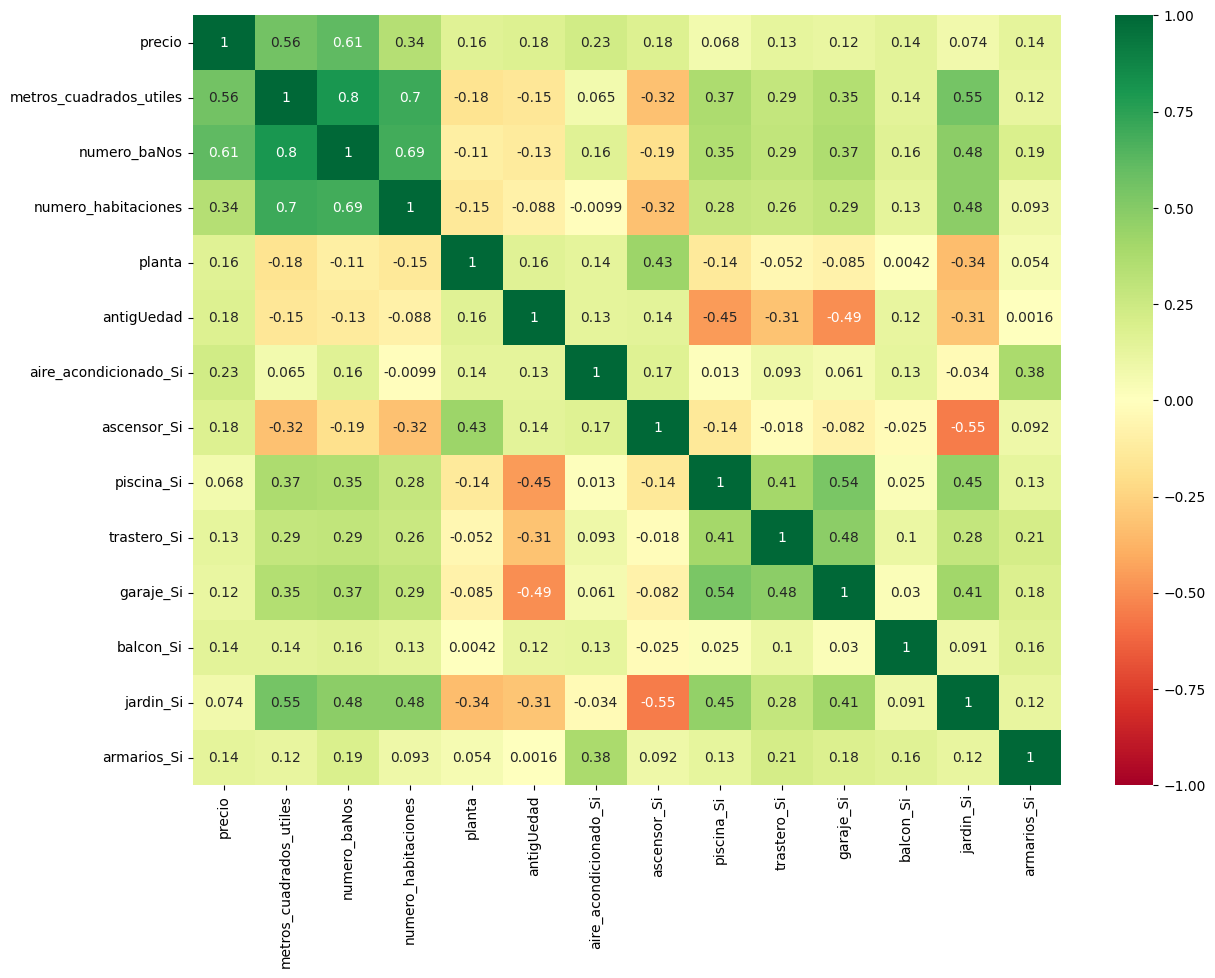

In [72]:
# Otro Gráfico con la matriz de correlación entre todas las variables.
plt.figure(figsize=(14,10))
sns.heatmap(correlations, annot=True, cmap='RdYlGn', vmin=-1, vmax=1)
plt.show()

/var/folders/jq/vg6hqkr57rbbsd6xq59b8l940000gn/T/ipykernel_34187/2785882188.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlaciones.values, y=correlaciones.index, palette="coolwarm")


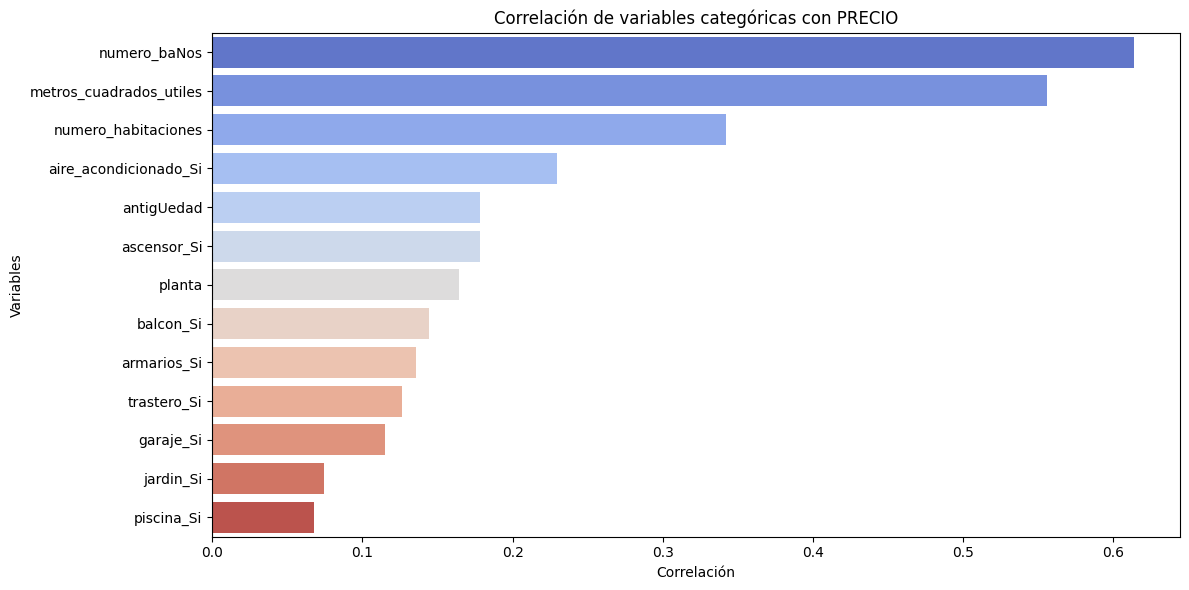

In [73]:
datos_sin_precio = datos_def.drop('precio', axis=1)
correlaciones = datos_sin_precio.corrwith(datos_def["precio"]).sort_values(ascending=False)

# Gráfico
plt.figure(figsize=(12, 6))
sns.barplot(x=correlaciones.values, y=correlaciones.index, palette="coolwarm")
plt.title(f'Correlación de variables categóricas con PRECIO')
plt.xlabel('Correlación')
plt.ylabel('Variables')
plt.axvline(0, color='gray', linestyle='--')
plt.tight_layout()
plt.show()

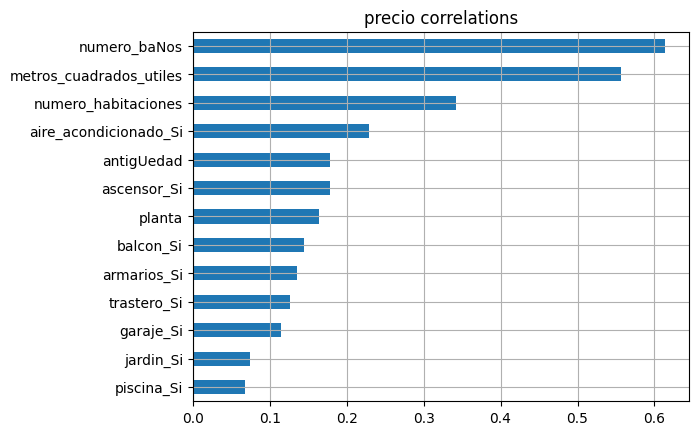

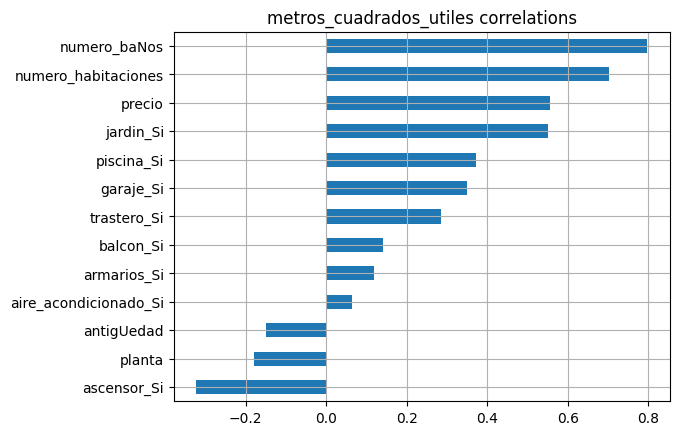

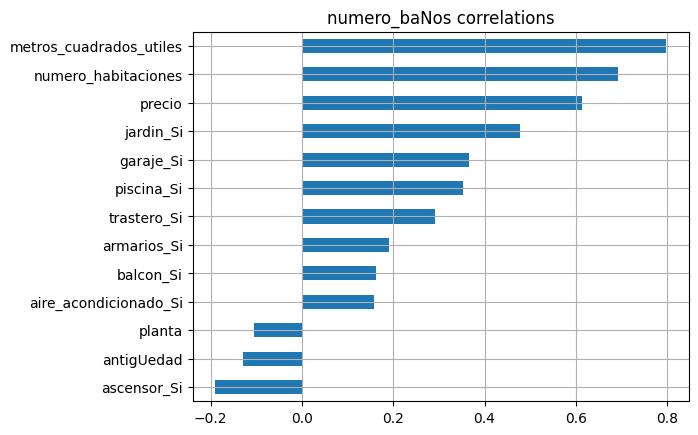

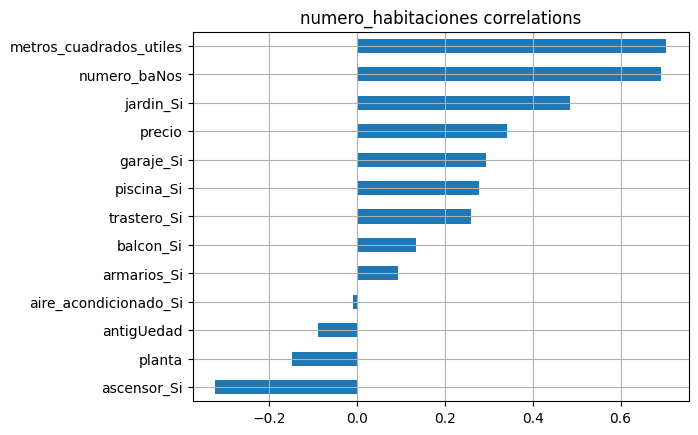

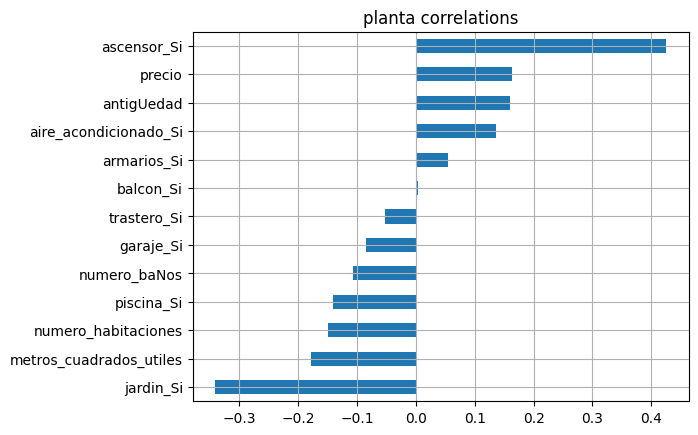

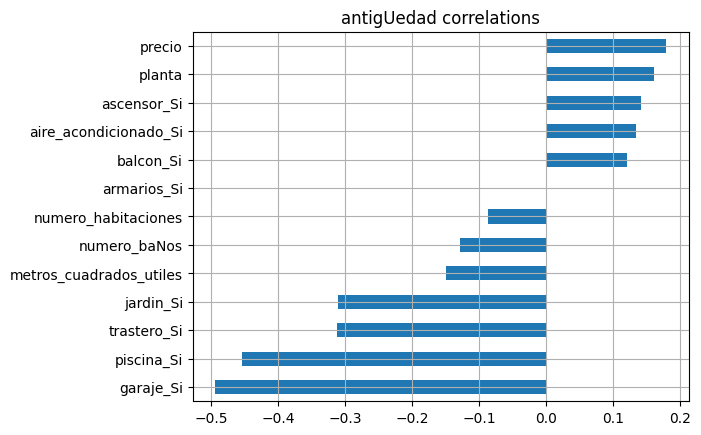

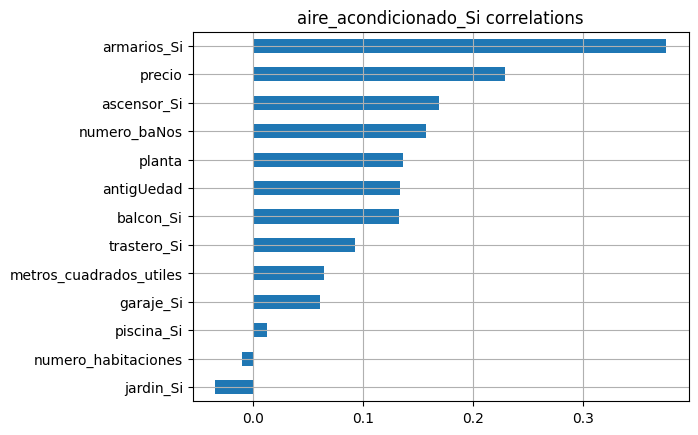

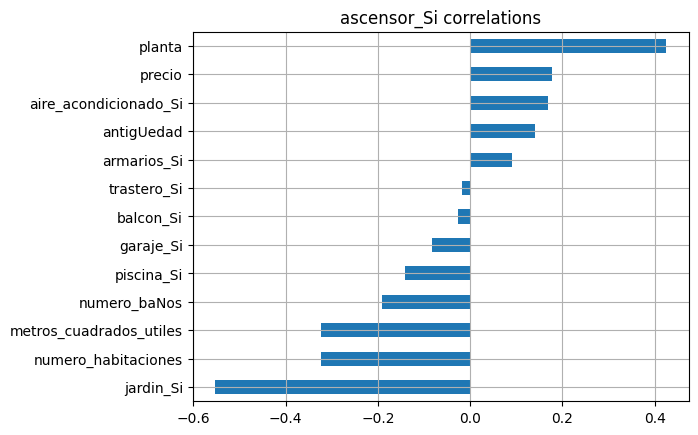

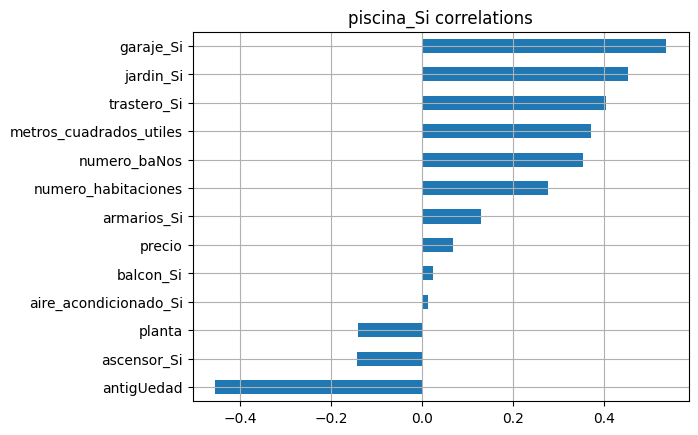

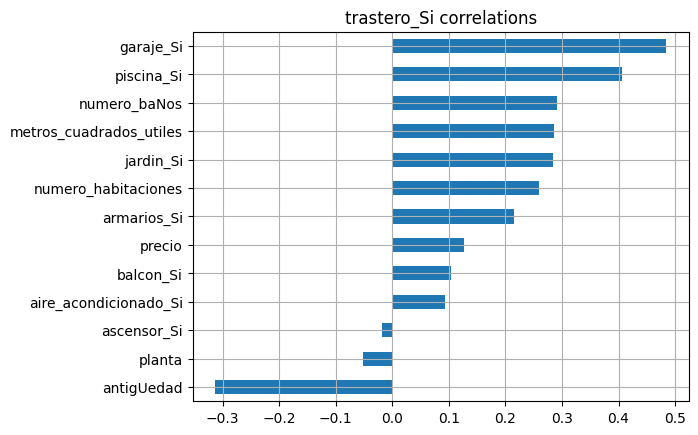

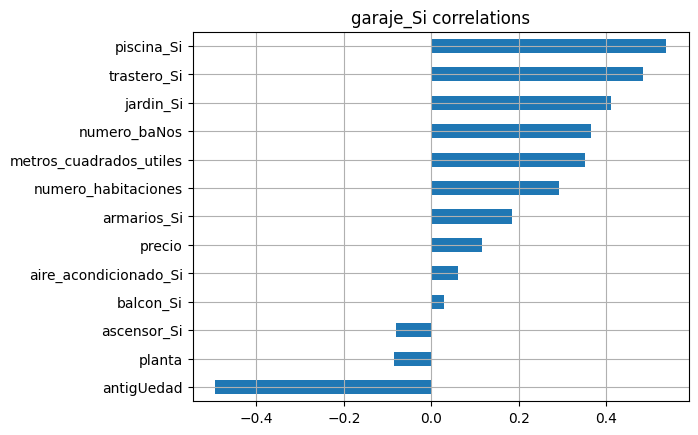

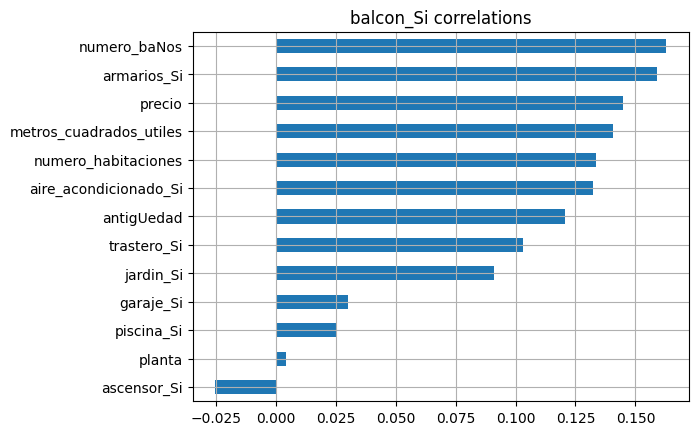

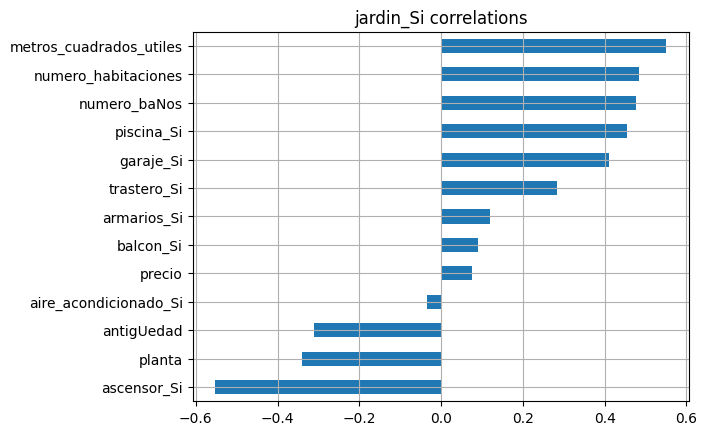

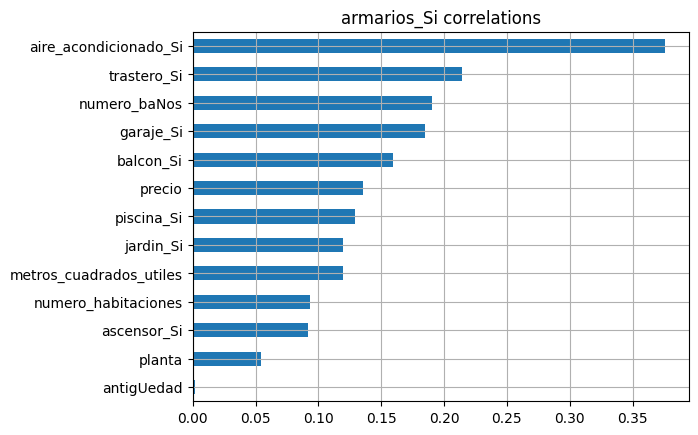

In [74]:
for var in datos_def.columns:
    (correlations[var].sort_values(ascending=True).drop(var).plot.barh(title=f'{var} correlations', grid=True));
    plt.show()

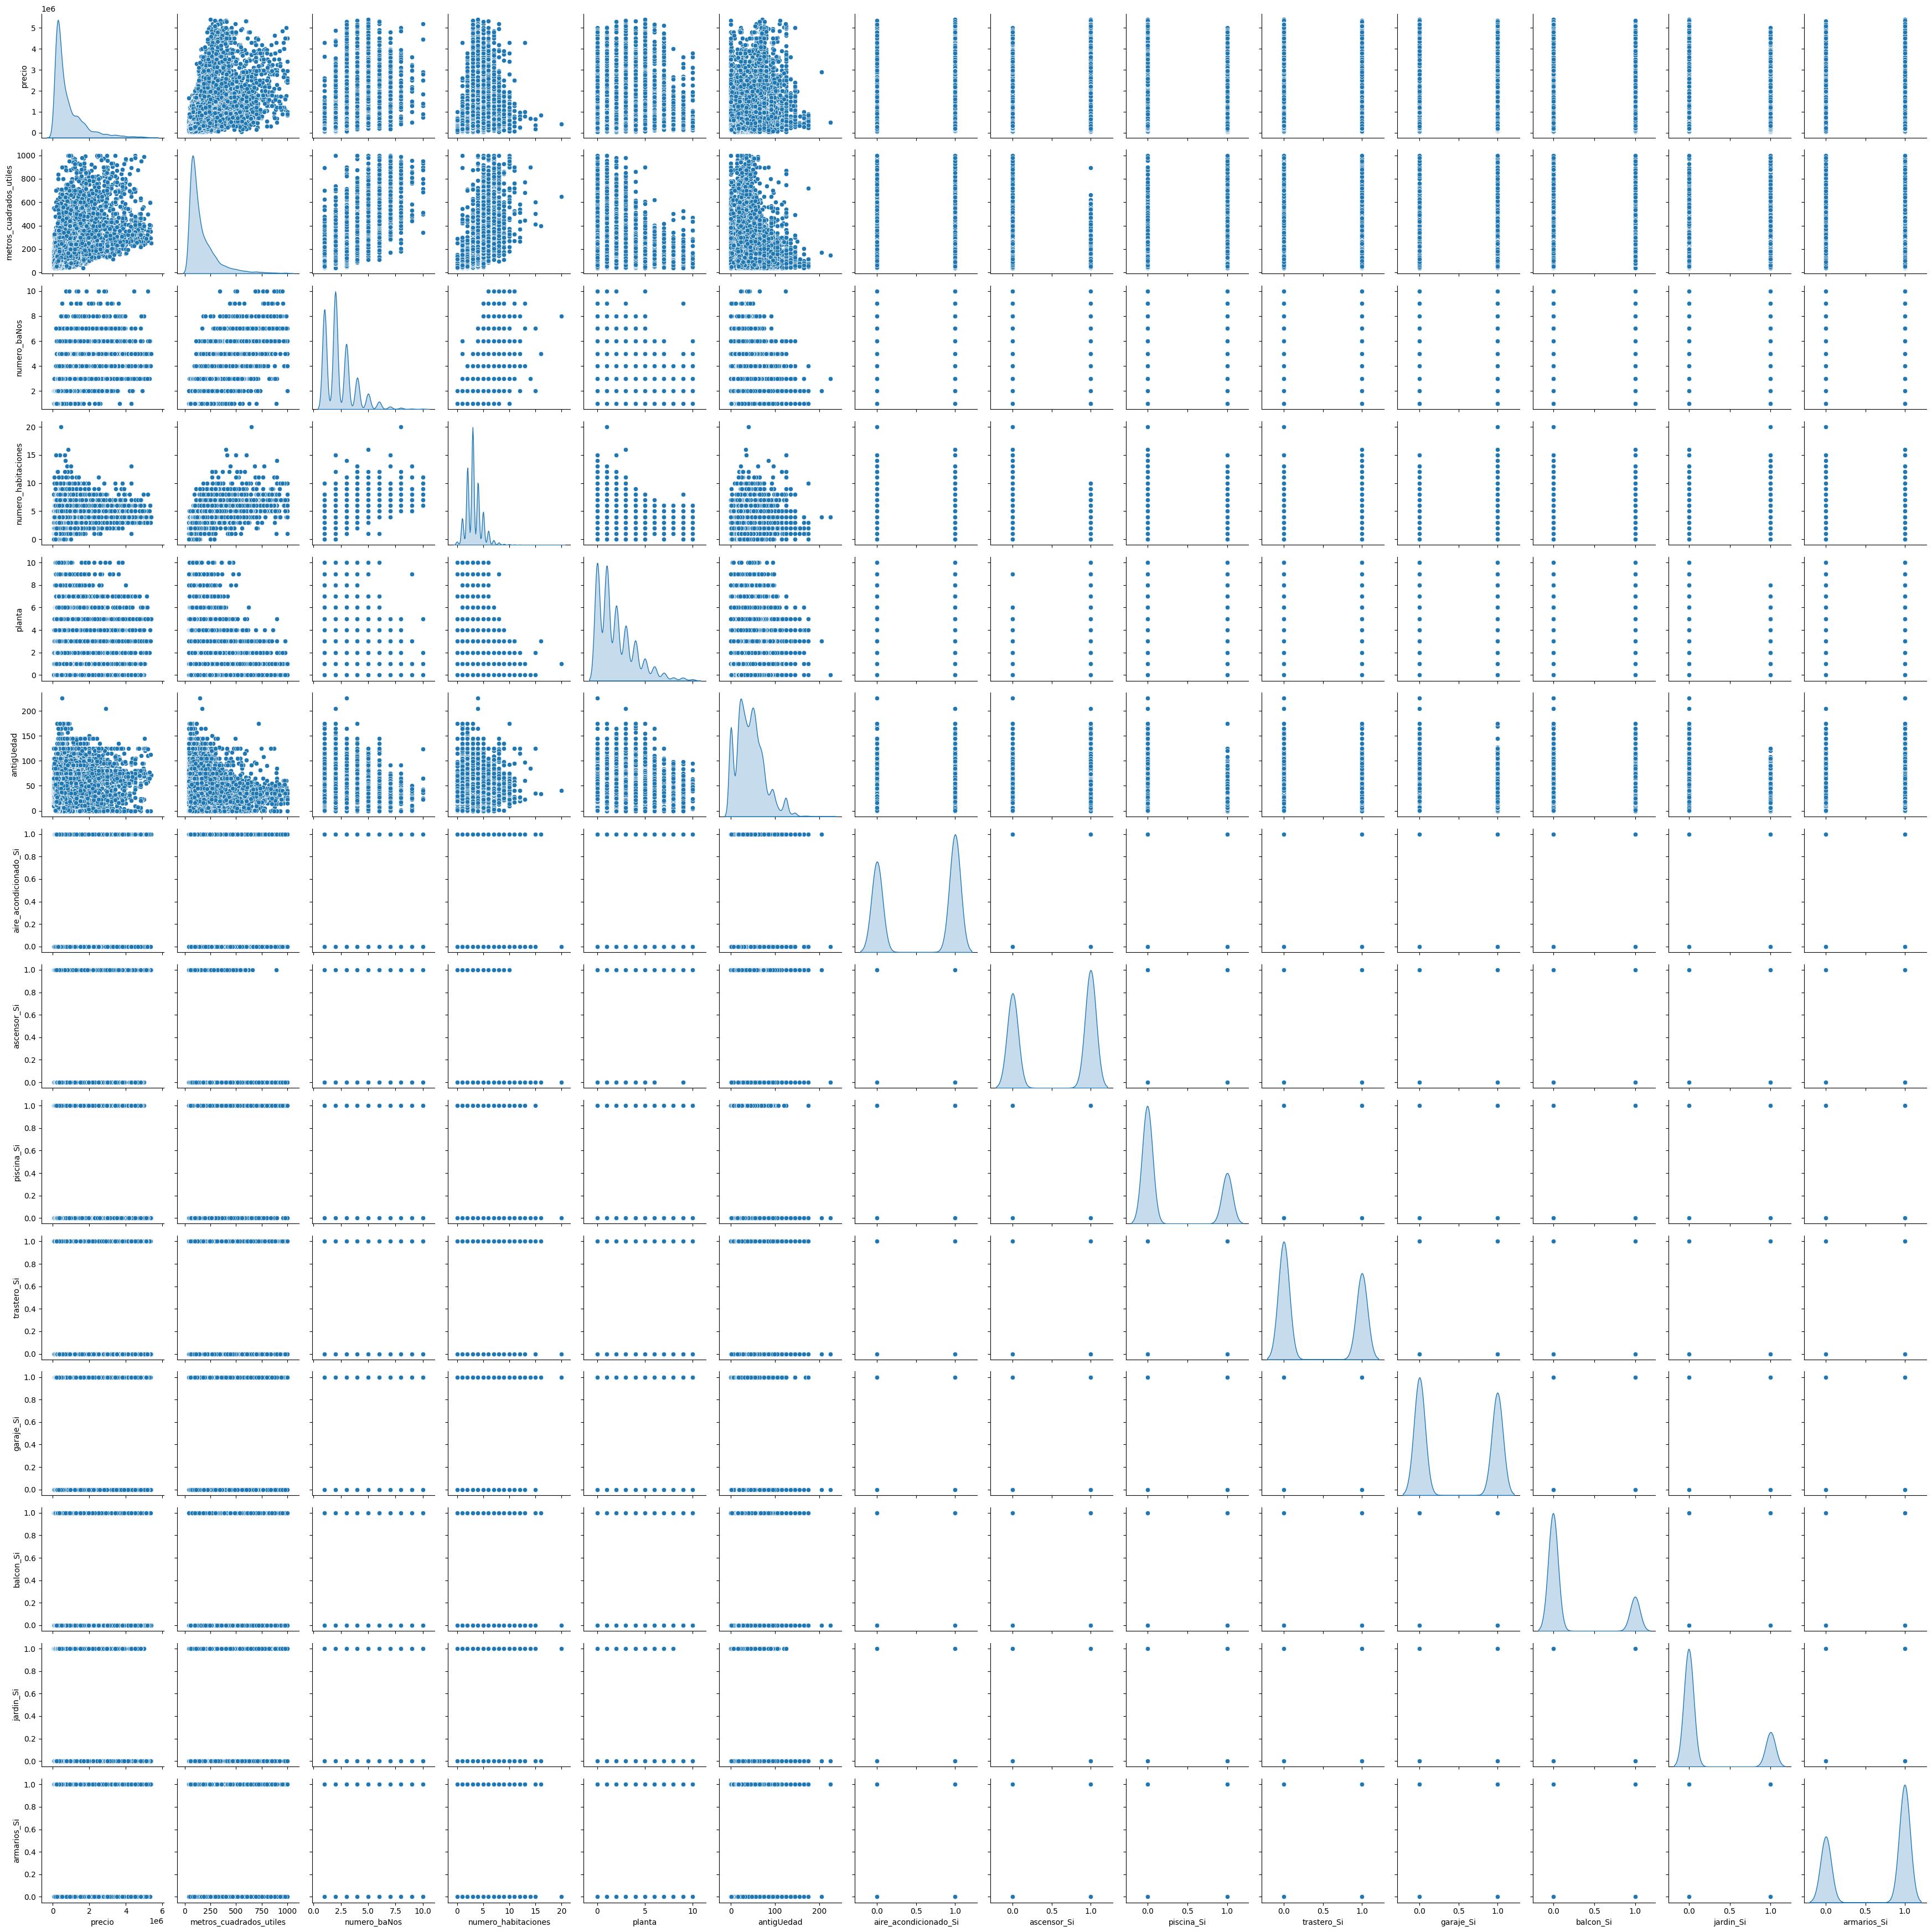

In [75]:
sns.pairplot(data=datos_def, diag_kind='kde', height=2.5)
plt.tight_layout()
plt.show()

ANÁLISIS VIF

In [81]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

datos_def_sin_precio = datos_def.drop("precio", axis=1)

datos_def_sin_precio = datos_def_sin_precio.replace({True: 1, False: 0})

vif_data = pd.DataFrame()
vif_data["feature"] = datos_def_sin_precio.columns
vif_data["VIF"] = [
    variance_inflation_factor(datos_def_sin_precio.values, i)
    for i in range(datos_def_sin_precio.shape[1])
]

print(vif_data)

                    feature        VIF
0   metros_cuadrados_utiles   8.061060
1              numero_baNos  13.277344
2       numero_habitaciones  10.572152
3                    planta   2.507379
4                antigUedad   3.720651
5     aire_acondicionado_Si   2.900079
6               ascensor_Si   3.561014
7                piscina_Si   2.423860
8               trastero_Si   2.485094
9                 garaje_Si   3.445210
10                balcon_Si   1.391865
11                jardin_Si   2.943586
12              armarios_Si   3.455768


/var/folders/jq/vg6hqkr57rbbsd6xq59b8l940000gn/T/ipykernel_34187/4107766442.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  datos_def_sin_precio = datos_def_sin_precio.replace({True: 1, False: 0})


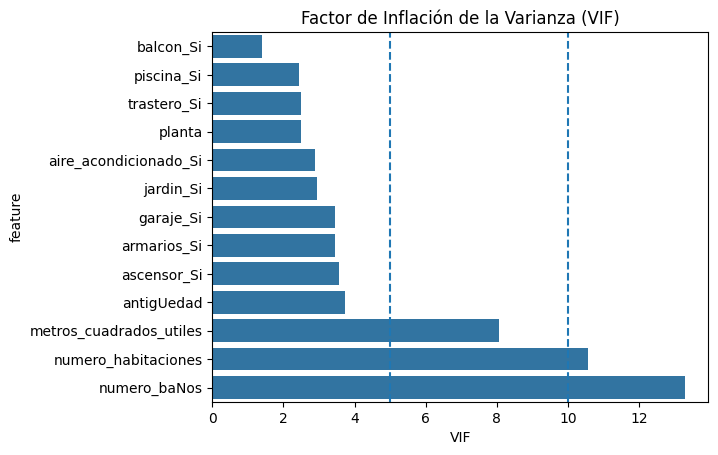

In [84]:
vif_sorted = vif_data.sort_values("VIF", ascending=True)

plt.figure()
sns.barplot(x="VIF", y="feature", data=vif_sorted)
plt.axvline(x=5, linestyle="--")   # umbral warning
plt.axvline(x=10, linestyle="--")  # umbral crítico
plt.title("Factor de Inflación de la Varianza (VIF)")
plt.show()

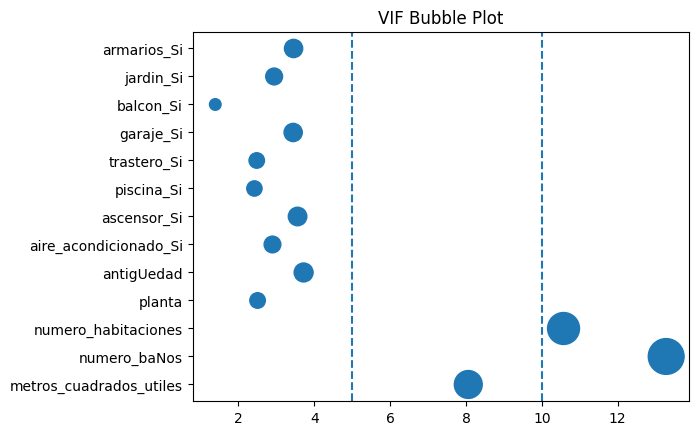

In [83]:
plt.figure()

plt.scatter(
    vif_data["VIF"],
    vif_data["feature"],
    s=vif_data["VIF"] * 50
)

plt.axvline(x=5, linestyle="--")
plt.axvline(x=10, linestyle="--")
plt.title("VIF Bubble Plot")
plt.show()

**Aplicación PCA**

In [15]:
# Estandarizamos/Normalizamos
from sklearn.preprocessing import StandardScaler

data_norm =  StandardScaler().fit_transform(datos_sin_precio)
pd.DataFrame(data_norm).describe().T

,count,mean,std,min,25%,50%,75%,max
0,16923.0,-2.687156e-17,1.00003,-0.903522,-0.638935,-0.353459,0.280157,5.780781
1,16923.0,-1.749275e-16,1.00003,-1.003741,-1.003741,-0.276774,0.450193,5.538959
2,16923.0,7.389678e-17,1.00003,-2.150778,-0.816432,-0.149259,0.517913,11.192678
3,16923.0,7.389678e-17,1.00003,-1.010554,-1.010554,-0.503494,0.510625,4.060044
4,16923.0,-6.046100e-17,1.00003,-1.416670,-0.741242,-0.097978,0.545286,5.820054
5,16923.0,1.007683e-17,1.00003,-1.140426,-1.140426,0.876865,0.876865,0.876865
6,16923.0,8.733256e-17,1.00003,-1.115940,-1.115940,0.896105,0.896105,0.896105
7,16923.0,-2.519208e-17,1.00003,-0.655676,-0.655676,-0.655676,1.525143,1.525143
8,16923.0,-1.259604e-16,1.00003,-0.855237,-0.855237,-0.855237,1.169267,1.169267
9,16923.0,-1.343578e-17,1.00003,-0.933041,-0.933041,-0.933041,1.071765,1.071765


(16923, 12)
[0.31675982 0.45575396 0.57966476 0.66003668 0.72766704 0.77649601
 0.82372846 0.8674008  0.90556363 0.93764119 0.96299431 0.98565575]


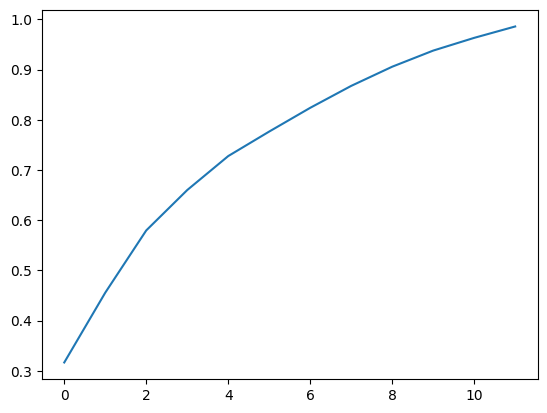

In [16]:
# Importamos el módulo que nos permite implementar el PCA
from sklearn.decomposition import PCA

# Veamos cuanta de la varianza es explicada por cada componente principal. Este PCA sería idéntico a escoger todas las variables ya que teníamos 11
# No tendría sentido aplciar PCA11 ya que no estaríamso reduciendo la dicmensionalidad.
pca_12 = PCA(12)
data_proj = pca_12.fit_transform(data_norm)
print(data_proj.shape)

cumvar = np.cumsum(pca_12.explained_variance_ratio_)
print(cumvar)
plt.plot(cumvar)

Podemos observar que la primera variable explica el 31%  de la varianza, la segunda el 14% de la varianza y la tercera el 12%...y así sucesivamente. Es decir, entre las 3 componentes principales
se acumula el 58% de la información de los datos.

A partir de 4 variable que ya solo aporta un 9%, el resto aportan bastante poco; pero cada variable aporta su granito de arena. La variable que menos aporta es un 2%.

Donde alcanzamos el 85% de la varianza es cogiendo 8 componentes, por lo que el PCA "optimo" sería un PCA8

(16923, 2)
[0.31675982 0.45575396]


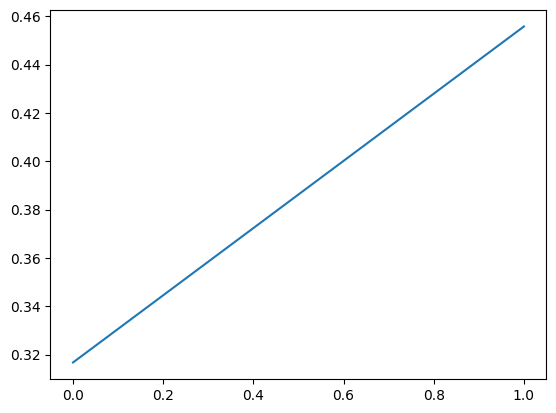

In [17]:
# Para poder ver los datos en 2 dimensiones, vamos a utilizar un PCA con n_componentes=2.
pca_2 = PCA(2)
data_proj2 = pca_2.fit_transform(data_norm)
print(data_proj2.shape)
cumvar = np.cumsum(pca_2.explained_variance_ratio_)
print(cumvar)
plt.plot(cumvar)

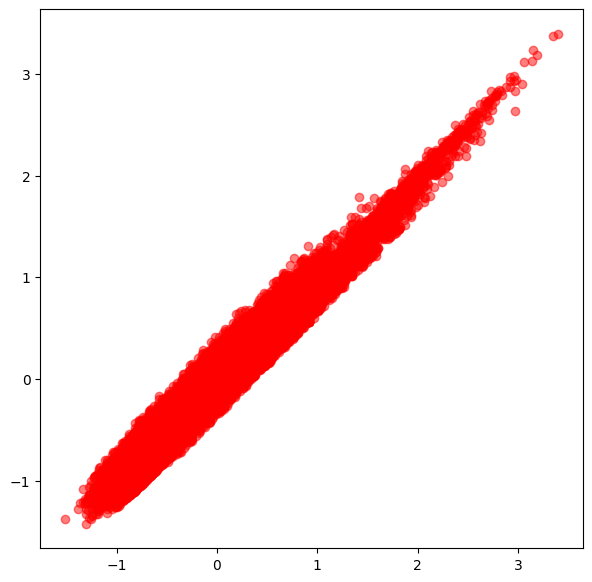

In [18]:
# Convertimos los datos en la nueva proyección.
X_rebuild = pca_2.inverse_transform(data_proj2)

# Pintamos los datos proyectados en 2 dimensiones.
plt.figure(figsize=(7, 7))
plt.scatter(X_rebuild[:, 0], X_rebuild[:, 1], alpha=0.5, c='r')

(16923, 9)
[0.31675982 0.45575396 0.57966476 0.66003668 0.72766704 0.77649601
 0.82372846 0.8674008  0.90556363]


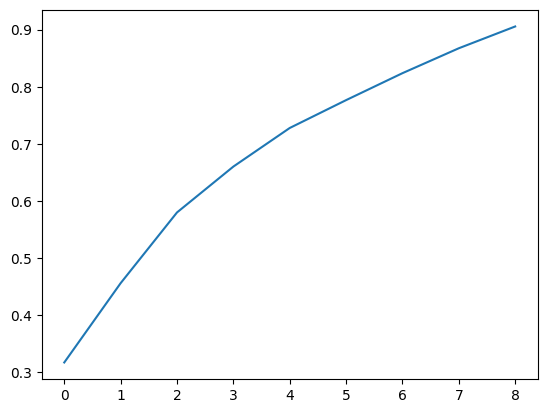

In [19]:
# PCA 9
pca_9 = PCA(9)
data_proj3 = pca_9.fit_transform(data_norm)
print(data_proj3.shape)
cumvar = np.cumsum(pca_9.explained_variance_ratio_)
print(cumvar)
plt.plot(cumvar)

Ahora toca decidir el número de componentes principales que necesitamos para optimizar el conjunto de datos y eliminar la redundancia (variables altamente correlacionadas entre sí).

Hay que tener cuidado con la pérdida de información, ya que con una pérdida notable ningún modelo machine learning funcionará correctamente.

Como estimación personal, trabajar con más de un 85% de la información es suficiente para obtener buenos resultados en la aplicación de modelos. Obviamente, si se quieren asegurar mejores resultados (aunque esta afirmación se tendría que estudiar, pues hay casos que puedan contradecirlo), se deberán elegir el número de componentes principales que se necesiten para conseguir por lo menos un 95% de la información, que ya sería un porcentaje de información bastante óptimo.

En este caso, con 9 componentes principales se conseguiría el 90% de la información del conjunto de datos, que está muy bien. El 85% se consigue con 8 componentes principales, lo que siguen siendo muchas.

Veamos el método del CODO para sacar más conclusiones y decidir.

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(datos_sin_precio)

In [21]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X_scaled)

PCA()

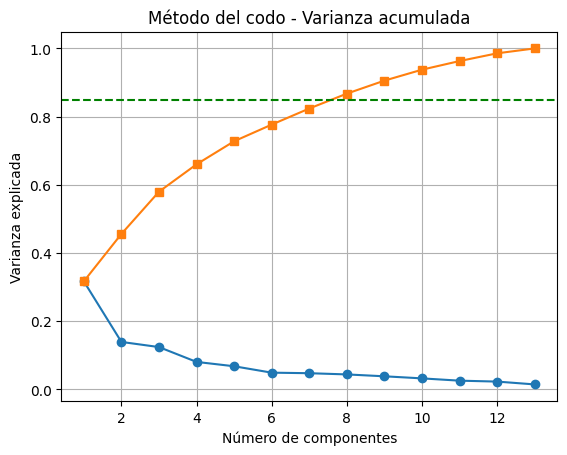

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Varianza explicada por cada componente
explained_variance = pca.explained_variance_ratio_

# Número de componentes
components = np.arange(1, len(explained_variance) + 1)

#varianza acumulada
cumulative_variance = np.cumsum(explained_variance)

# Gráfico
plt.figure()
plt.plot(components, explained_variance, marker='o')
plt.plot(components, cumulative_variance, marker='s', label="Varianza acumulada")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada")
plt.title("Método del codo - Varianza acumulada")
plt.axhline(y=0.85, color='g', linestyle='--', label="85% varianza")
plt.grid()

plt.show()

No parece que usar PCA vaya a mejorar ni siqueira el rendimiento por lo que seguramente habrá que descartar su uso.
Para concluir, probamos modelo de regresion linear multivariante y comprobamos que los resultados con PCA empeoran.

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(datos_sin_precio, datos_def['precio'], train_size= 0.8, random_state=99, shuffle=True)

X_train.head()

,metros_cuadrados_utiles,numero_baNos,numero_habitaciones,planta,antigUedad,aire_acondicionado_Si,ascensor_Si,piscina_Si,trastero_Si,garaje_Si,balcon_Si,jardin_Si,armarios_Si
id,,,,,,,,,,,,,
952,182,2,4,2,0,False,True,True,True,True,False,False,False
2496,150,2,2,3,77,True,True,False,True,True,True,False,True
10256,220,4,5,1,72,True,True,False,True,True,True,False,True
3543,150,2,3,6,71,True,True,False,False,False,False,False,False
1335,81,1,3,1,35,False,False,False,False,False,False,False,True


In [24]:
# Estandarizamos/Normalizamos
from sklearn.preprocessing import StandardScaler

estandarizacion = StandardScaler()
estandarizacion.fit(X_train)
data_train_norm = estandarizacion.transform(X_train)
data_test_norm = estandarizacion.transform(X_test)

pd.DataFrame(data_train_norm, columns=X_train.columns.values).describe()

,metros_cuadrados_utiles,numero_baNos,numero_habitaciones,planta,antigUedad,aire_acondicionado_Si,ascensor_Si,piscina_Si,trastero_Si,garaje_Si,balcon_Si,jardin_Si,armarios_Si
count,1.353800e+04,1.353800e+04,1.353800e+04,1.353800e+04,1.353800e+04,1.353800e+04,1.353800e+04,1.353800e+04,1.353800e+04,1.353800e+04,1.353800e+04,1.353800e+04,1.353800e+04
mean,8.397610e-17,-1.056262e-16,9.867191e-17,-3.568984e-17,5.878327e-17,-9.552281e-17,9.237370e-17,-2.519283e-17,-1.574552e-17,-3.096619e-17,-5.327234e-17,-5.248506e-18,8.712520e-17
std,1.000037e+00,1.000037e+00,1.000037e+00,1.000037e+00,1.000037e+00,1.000037e+00,1.000037e+00,1.000037e+00,1.000037e+00,1.000037e+00,1.000037e+00,1.000037e+00,1.000037e+00
min,-9.042426e-01,-1.001906e+00,-2.145926e+00,-1.011729e+00,-1.421937e+00,-1.138307e+00,-1.110521e+00,-6.536867e-01,-8.554919e-01,-9.343414e-01,-5.380113e-01,-5.408640e-01,-1.329001e+00
25%,-6.391398e-01,-1.001906e+00,-8.158488e-01,-1.011729e+00,-7.455089e-01,-1.138307e+00,-1.110521e+00,-6.536867e-01,-8.554919e-01,-9.343414e-01,-5.380113e-01,-5.408640e-01,-1.329001e+00
50%,-3.531079e-01,-2.742340e-01,-1.508102e-01,-5.050413e-01,-1.012913e-01,8.784974e-01,9.004784e-01,-6.536867e-01,-8.554919e-01,-9.343414e-01,-5.380113e-01,-5.408640e-01,7.524447e-01
75%,2.817434e-01,4.534375e-01,5.142284e-01,5.083349e-01,5.429263e-01,8.784974e-01,9.004784e-01,1.529785e+00,1.168918e+00,1.070273e+00,-5.380113e-01,-5.408640e-01,7.524447e-01
max,5.793090e+00,5.547138e+00,1.115485e+01,4.055152e+00,5.825510e+00,8.784974e-01,9.004784e-01,1.529785e+00,1.168918e+00,1.070273e+00,1.858697e+00,1.848894e+00,7.524447e-01


In [25]:
from sklearn.linear_model import LinearRegression
modelo_regresion = LinearRegression()
modelo_regresion.fit(data_train_norm, y_train)

# Predecimos
y_pred_regresion = modelo_regresion.predict(data_test_norm)

from sklearn.metrics import mean_absolute_error
MAE_regresion = mean_absolute_error(y_test, y_pred_regresion)
MAE_regresion

363024.90201989515

In [26]:
# Aplicamos el PCA óptimo detectado por si los resultados fuesen favorables. 
# Si fuesen 11 componentes principales sería lo mismo que no aplicar PCA.

pca_8 = PCA(8)
pca_8.fit(data_train_norm)
data_train_pca8 = pca_8.transform(data_train_norm)
data_test_pca8 = pca_8.transform(data_test_norm)

In [27]:
modelo_regresion = LinearRegression()
modelo_regresion.fit(data_train_pca8, y_train)

# Predecimos
y_pred_regresion = modelo_regresion.predict(data_test_pca8)

from sklearn.metrics import mean_absolute_error
MAE_regresion = mean_absolute_error(y_test, y_pred_regresion)
MAE_regresion

395776.3414512582

El uso de PCA no mejora los resultados (sin PCA MAE=363024; con PCA8 MAE=395776), de hecho empeora; por lo que descartaré el uso de PCA. Las componentes principales descartadas para el PCA si que explicaban un poco la variable "objetivo" y por tanto se tendrán que añadir al modelo.

MODELOS - ML

# **APLICACIÓN DE MODELOS SUPERVISADOS PARA PREDECIR VARIABLE NUMÉRICA .**

In [56]:
# Para decidir que modelo escogemos, necesitamos poder testar con resultados que conocemos.

# Utilizamos la función train_test_split para dividir en datos de entrada y de salida tanto para entrenamiento como para test.
# La partición será de 70-30 para entrenamiento y test respectivamente.
# Como los datos están ordenados por fecha y ciudad, hay que barajarlos para no añadir sesgos al modelo, por ello indicamos el parámetro "shuffle = True".
# Con el fin de poder testar diferentes modelos con la misma distribución entrenamiento-test fijamos la semilla "random_state = 99".
# X=datos_sin_precio, Y=datos_def['precio']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(datos_sin_precio, datos_def['precio'], train_size= 0.8, random_state=99, shuffle=True)

X_train.head()

,metros_cuadrados_utiles,numero_baNos,numero_habitaciones,planta,antigUedad,aire_acondicionado_Si,ascensor_Si,piscina_Si,trastero_Si,garaje_Si,balcon_Si,jardin_Si,armarios_Si
id,,,,,,,,,,,,,
952,182,2,4,2,0,False,True,True,True,True,False,False,False
2496,150,2,2,3,77,True,True,False,True,True,True,False,True
10256,220,4,5,1,72,True,True,False,True,True,True,False,True
3543,150,2,3,6,71,True,True,False,False,False,False,False,False
1335,81,1,3,1,35,False,False,False,False,False,False,False,True


In [57]:
# Estandarizamos/Normalizamos -> Solo aplica a las variables numéricas, las Dummies se quedan sin estandarizar ya que no es necesario.
from sklearn.preprocessing import StandardScaler


variables_numericas = [
    'metros_cuadrados_utiles',
    'numero_baNos',
    'numero_habitaciones',
    'planta',
    'antigUedad'
]

variables_dummies = [
    'aire_acondicionado_Si',
    'ascensor_Si',
    'piscina_Si',
    'trastero_Si',
    'garaje_Si',
    'balcon_Si',
    'jardin_Si',
    'armarios_Si'
]

estandarizacion = StandardScaler()
estandarizacion.fit(X_train)
X_train_num = scaler.fit_transform(X_train[variables_numericas])
X_test_num = scaler.transform(X_test[variables_numericas])

X_train_scaled = pd.DataFrame(X_train_num, columns=variables_numericas, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_num, columns=variables_numericas, index=X_test.index)

# Añadir dummies sin tocar
X_train_final = pd.concat([X_train_scaled, X_train[variables_dummies]], axis=1)
X_test_final = pd.concat([X_test_scaled, X_test[variables_dummies]], axis=1)

pd.DataFrame(X_train_final, columns=X_train_final.columns.values).describe()

#print(X_train_final.head(5))

,metros_cuadrados_utiles,numero_baNos,numero_habitaciones,planta,antigUedad
count,1.353800e+04,1.353800e+04,1.353800e+04,1.353800e+04,1.353800e+04
mean,8.397610e-17,-1.056262e-16,9.867191e-17,-3.568984e-17,5.878327e-17
std,1.000037e+00,1.000037e+00,1.000037e+00,1.000037e+00,1.000037e+00
min,-9.042426e-01,-1.001906e+00,-2.145926e+00,-1.011729e+00,-1.421937e+00
25%,-6.391398e-01,-1.001906e+00,-8.158488e-01,-1.011729e+00,-7.455089e-01
50%,-3.531079e-01,-2.742340e-01,-1.508102e-01,-5.050413e-01,-1.012913e-01
75%,2.817434e-01,4.534375e-01,5.142284e-01,5.083349e-01,5.429263e-01
max,5.793090e+00,5.547138e+00,1.115485e+01,4.055152e+00,5.825510e+00


# **1 - MODELOS LINEALES**

## **Regresión Lineal Multivariante.**

In [30]:
from sklearn.linear_model import LinearRegression
modelo_regresion = LinearRegression()
modelo_regresion.fit(X_train_final, y_train)

# Predecimos
y_pred_regresion = modelo_regresion.predict(X_test_final)

from sklearn.metrics import mean_absolute_error, r2_score
MAE_regresion = mean_absolute_error(y_test, y_pred_regresion)
r2_regresion = r2_score(y_test, y_pred_regresion)

MAE_regresion, r2_regresion

(363024.9020198951, 0.5998814324989901)


MAE (Mean Absolute Error):
Mide el error absoluto promedio en las mismas unidades que la variable objetivo (€ en tu caso).
Muy intuitivo para entender “cuánto se equivoca el modelo en promedio”.

RMSE (Root Mean Squared Error):
Penaliza más los errores grandes porque eleva al cuadrado la diferencia antes de promediar.
Útil si quieres detectar que los outliers impactan fuertemente en el ajuste.

R² (Coeficiente de determinación):
Proporción de la variabilidad de la variable objetivo explicada por el modelo.
Bueno para comparar ajustes relativos entre modelos.

MAPE (Mean Absolute Percentage Error):
Da una idea del error relativo respecto al valor real en porcentaje.
Muy útil cuando los valores de la variable objetivo varían mucho, como en tu caso con precios muy diferentes.
Puede dispararse con precios muy bajos, pero con viviendas esto suele ser menos problemático porque casi todos los precios son grandes.


--> MAE y RMSE muestran el error en unidades monetarias, R² indica fuerza de explicación, y MAPE ofrece perspectiva relativa.


In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_regresion)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_regresion))
r2 = r2_score(y_test, y_pred_regresion)
mape = np.mean(np.abs((y_test - y_pred_regresion) / y_test)) * 100

print(f"MAE: {mae:,.0f} €")
print(f"RMSE: {rmse:,.0f} €")
print(f"R²: {r2:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE: 363,025 €
RMSE: 549,136 €
R²: 0.60
MAPE: 68.64%


In [32]:
#MOSTRAMOS LOS COEFICIENTES

# Recuperar desviación estándar de cada variable
stds = estandarizacion.scale_

# Coeficientes originales
coef_original = modelo_regresion.coef_ / stds

# Ajustar intercepto a escala original
intercepto_original = modelo_regresion.intercept_ - sum(coef_original * estandarizacion.mean_)

coeficientes = pd.DataFrame({
    'Variable': X_train.columns,
    'Coeficiente (€ por unidad)': coef_original
}).sort_values(by='Coeficiente (€ por unidad)', ascending=False)

print(coeficientes)
print("Intercepto original:", intercepto_original)

                   Variable  Coeficiente (€ por unidad)
6               ascensor_Si               829656.864490
1              numero_baNos               298450.885641
5     aire_acondicionado_Si               162192.595877
3                    planta                46514.558488
9                 garaje_Si                35510.396249
10                balcon_Si                25436.575670
8               trastero_Si                18077.262137
4                antigUedad                 5369.579125
0   metros_cuadrados_utiles                 2771.012515
2       numero_habitaciones               -90208.762740
12              armarios_Si              -116880.581131
7                piscina_Si              -237176.093841
11                jardin_Si              -369968.423435
Intercepto original: -924670.492751037


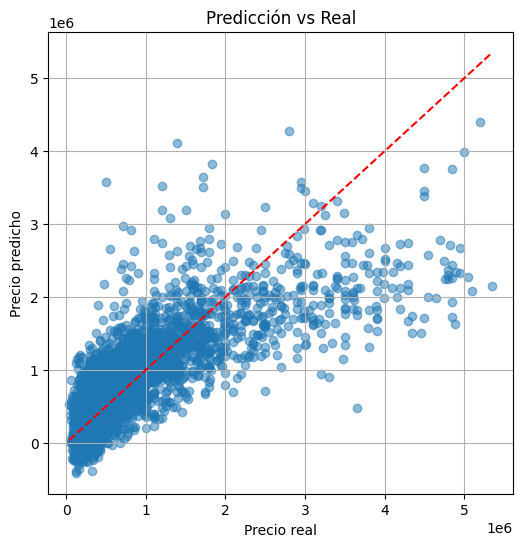

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_regresion, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("Predicción vs Real")
plt.grid(True)
plt.show()

Predicciones demasiado dispersas, aunque para viviendas de menor de menos de 2M los resUltados MAE no serían tan abultados.

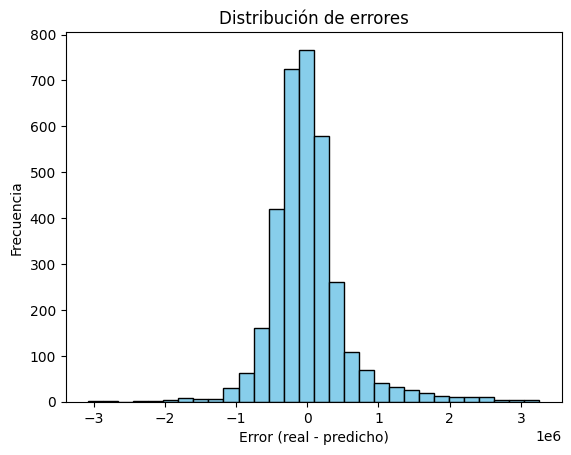

In [34]:
errors = y_test - y_pred_regresion
plt.hist(errors, bins=30, color='skyblue', edgecolor='black')
plt.title("Distribución de errores")
plt.xlabel("Error (real - predicho)")
plt.ylabel("Frecuencia")
plt.show()

La mayoría de valores tienen errores cercanos a 0, lo que afirma que pocas viviendas (las atípicas) distorsionan demasiado el modelo.

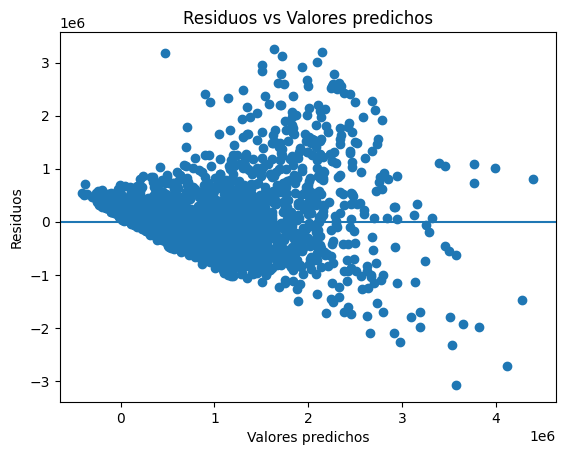

In [35]:

plt.figure()
plt.scatter(y_pred_regresion, errors)
plt.axhline(y=0)  # línea horizontal en 0
plt.xlabel("Valores predichos")
plt.ylabel("Residuos")
plt.title("Residuos vs Valores predichos")
plt.show()


Los residuos no están uniformemente distribuidos, lo que indica heterocedasticidad y limitaciones del modelo lineal.

-No está capturando completamente la relación entre las variables predictoras y el precio.

-Podría estar omitiendo variables importantes o está usando un modelo demasiado simple (como una regresión lineal cuando hay relaciones no lineales).

In [36]:
#PARA PODER OBTENER MÁS INFORMACIÓN DE LA REGRESIÓN
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

# 1. División train-test
X_train, X_test, y_train, y_test = train_test_split(datos_sin_precio, datos_def['precio'], train_size=0.80, random_state=99, shuffle=True)

X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')

X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

X_train = X_train.astype(float)
X_test = X_test.astype(float)

# 2. Añadir constante
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

# 3. Modelo
modelo = sm.OLS(y_train, X_train_const).fit()

# 4. Predicción
y_pred = modelo.predict(X_test_const)

# 5. Métricas
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MAE: {mae:,.0f} €")
print(f"RMSE: {rmse:,.0f} €")
print(f"R²: {r2:.2f}")
print(f"MAPE: {mape:.2f}%")

# 6. Coeficientes (interpretables directamente)
print("Intercepto:", modelo.params[0])
for param, coef in zip(X_train.columns, modelo.params[1:]):
    print(f"{param}: {coef}")

# 7. Summary completo
print(modelo.summary())

# 8. P-values
print(modelo.pvalues.sort_values())


MAE: 363,025 €
RMSE: 549,136 €
R²: 0.60
MAPE: 68.64%
Intercepto: -574438.0349684
metros_cuadrados_utiles: 2771.012515205257
numero_baNos: 298450.8856413259
numero_habitaciones: -90208.76273958958
planta: 46514.55848757706
antigUedad: 5369.579124515977
aire_acondicionado_Si: 80420.57587524762
ascensor_Si: 412559.52032429224
piscina_Si: -108623.3948678404
trastero_Si: 8929.644631726962
garaje_Si: 17714.331199216467
balcon_Si: 10613.12925220863
jardin_Si: -154814.20766266366
armarios_Si: -56153.549579581704
                            OLS Regression Results                            
Dep. Variable:                 precio   R-squared:                       0.596
Model:                            OLS   Adj. R-squared:                  0.596
Method:                 Least Squares   F-statistic:                     1537.
Date:                Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:22:16   Log-Likelihood:            -1.9789e+05
No. Observations

/var/folders/jq/vg6hqkr57rbbsd6xq59b8l940000gn/T/ipykernel_34187/1153605629.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("Intercepto:", modelo.params[0])


In [37]:
#agregar AIC y BIC 

print("AIC:", modelo.aic)
print("BIC:", modelo.bic)
print("R² ajustado:", modelo.rsquared_adj)

AIC: 395814.2021820306
BIC: 395919.38776358153
R² ajustado: 0.5959428789863388



# CONCLUSION

La regresión lineal no es adecuada para modelar precios de viviendas con alta dispersión y dependientes de múltiples factores no lineales y sesgados por ubicación.

Los coeficientes de las dummies reflejan impactos promedio, pero no capturan interacciones ni patrones complejos. Por ello, se utiliza principalmente como referencia inicial y base interpretativa para comparar con modelos más avanzados, como árboles, ensemble y boosting, que sí pueden capturar relaciones no lineales y efectos de interacción.




## **Regresión Polinomial**.

In [38]:
# Veamos si mejoramos el modelo aplicando un modelo de regresión polinómica de grado 3 para comprobar si se mejoran los resultados 
# y se captan mejor las relaciones "no-lineales" entre las variables predictoras y la variable objetivo (a predecir).
# He probado grado 2 y ya mejora, pero el grado que mejor MAE obtiene es grado 3. Para grado 4 o mayor los resultados empeoran exponencialmente.
from sklearn.preprocessing import PolynomialFeatures 

# usaremos todos los polinomios resultantes de grado 
polinomial = PolynomialFeatures(degree = 3,  include_bias=False)    

X_train_polinomial = polinomial.fit_transform(X_train_final)
X_test_polinomial = polinomial.transform(X_test_final)

modelo_polinomial = LinearRegression()
modelo_polinomial.fit(X_train_polinomial, y_train) #sin aplicar logaritmo sobre y_train

# Predecimos
y_pred_polinomial = modelo_polinomial.predict(X_test_polinomial)


mae = mean_absolute_error(y_test, y_pred_polinomial)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_polinomial))
r2 = r2_score(y_test, y_pred_polinomial)
mape = np.mean(np.abs((y_test - y_pred_polinomial) / y_test)) * 100

print(f"MAE: {mae:,.0f} €")
print(f"RMSE: {rmse:,.0f} €")
print(f"R²: {r2:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE: 280,817 €
RMSE: 445,653 €
R²: 0.74
MAPE: 46.75%


--> Explicación Grados en el Modelo Polinomial.
Lo que se observa es un comportamiento clásico de sobreajuste en modelos polinomiales:
A partir del grado 3, el modelo se vuelve demasiado flexible, ajustándose al ruido y no a la tendencia real.
Esto reduce el error en entrenamiento pero empeora el rendimiento en test, lo que significa que pierde capacidad de generalización.
Grado 1 (lineal) → inframodelo (underfitting) Por tener demasiada STD en el variable objetivo.
Grado 2-3 → modelo más adecuado
Grado 4 o más → sobreajuste (overfitting)


--> INTERPRETACION DEL NUEVO MODELO
El modelo ahora explica un 72 % de la varianza del precio (R2), lo cual es muy decente para un problema de regresión inmobiliaria.
MAE y RMSE han bajado bastante: ahora el error medio está más cerca de los ~280 mil €, lo que es más razonable considerando que los precios llegan hasta más de 5 millones.
MAPE del 46.35 % aún es alto si se busca precisión, pero mejora significativamente.

## **RIDGE/LASSO**

In [39]:
from sklearn.linear_model import Ridge, Lasso

# Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_final, y_train)
y_pred_ridge = ridge.predict(X_test_final)

mae = mean_absolute_error(y_test, y_pred_ridge)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2 = r2_score(y_test, y_pred_ridge)
mape = np.mean(np.abs((y_test - y_pred_ridge) / y_test)) * 100

print(f"MAE: {mae:,.0f} €")
print(f"RMSE: {rmse:,.0f} €")
print(f"R²: {r2:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE: 363,011 €
RMSE: 549,139 €
R²: 0.60
MAPE: 68.63%


In [40]:
# Lasso
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_final, y_train)
y_pred_lasso = lasso.predict(X_test_final)

mae = mean_absolute_error(y_test, y_pred_lasso)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2 = r2_score(y_test, y_pred_lasso)
mape = np.mean(np.abs((y_test - y_pred_lasso) / y_test)) * 100

print(f"MAE: {mae:,.0f} €")
print(f"RMSE: {rmse:,.0f} €")
print(f"R²: {r2:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE: 363,025 €
RMSE: 549,136 €
R²: 0.60
MAPE: 68.64%


## **2 - Modelos Basados en distancia**.

## **KNN Vecinos Más Cercanos**.


**Parametrización**

Tendremos que decidir si utilizamos la métrica de "n_neighbors" o "radius" que conlleva la utilización de modelos diferentes.

En general, el número de vecinos se utiliza normalmente para datos uniformes.
Como se han normalizado los datos, han quedado más uniformes y será mejor optar por "KNeighbors" que por "RadiusNeighbors".
No se ha trabajado la selección del tipo de "distancia" que sería una opción a manejar.

APLICAMOS GRID_SEARCH_CV PARA LA PARAMETRIZACION CORRECTA Y UTILIZAR VALIDACION CRUZADA.
Vamos a optimizar KNeighborsRegressor verificando que el peso debe ser "distance" y que el número de vecinos (k) debe ser 8.

In [41]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import KFold

# =========================
# 0. ESTANDARIZACION POR TIPO DE VARIABLES
# =========================
preprocess = ColumnTransformer([
    ('num', StandardScaler(), variables_numericas),
    ('cat', 'passthrough', variables_dummies)
])

# =========================
# 1. PIPELINE (escala + modelo)
# =========================
pipe = Pipeline([
    ('preprocess', preprocess),
    ('knn', KNeighborsRegressor())
])

# =========================
# 2. GRID DE HIPERPARÁMETROS
# =========================
param_grid = {
    'knn__n_neighbors': [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 20, 30],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['minkowski', 'manhattan', 'chebyshev', 'euclidean'],
    'knn__p': [1,2]
}

# =========================
# 3. VALIDACIÓN CRUZADA
# =========================
cv = KFold(n_splits=10, shuffle=True, random_state=99)

# =========================
# 4. GRID SEARCH --> n_jobs es el numero de nucleos que se usa de mi computer (-1 son todos los disponibles)
# =========================
grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=cv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

# =========================
# 5. ENTRENAMIENTO
# =========================
grid_search.fit(X_train, y_train)

# Mejor modelo
best_knn = grid_search.best_estimator_

print("Mejores parámetros:", grid_search.best_params_)

# =========================
# 6. PREDICCIÓN FINAL
# =========================
y_pred_knn_ = best_knn.predict(X_test)

# =========================
# 7. MÉTRICAS
# =========================
mae = mean_absolute_error(y_test, y_pred_knn_)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_knn_))
r2 = r2_score(y_test, y_pred_knn_)
mape = np.mean(np.abs((y_test - y_pred_knn_) / y_test)) * 100

print(f"MAE: {mae:,.0f} €")
print(f"RMSE: {rmse:,.0f} €")
print(f"R²: {r2:.2f}")
print(f"MAPE: {mape:.2f}%")

Mejores parámetros: {'knn__metric': 'minkowski', 'knn__n_neighbors': 15, 'knn__p': 1, 'knn__weights': 'distance'}
MAE: 256,595 €
RMSE: 434,092 €
R²: 0.75
MAPE: 39.79%


## **3  - Modelos basados en árboles.**
## **Árboles de Decisión - Regresión.**

In [42]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(random_state=99)

param_grid = {
    'max_depth': [5,6, 7, 8, 9, 10, 10, 11, 12, 13, 14, 15, 20, 25, 30, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': [None, 'sqrt', 'log2']
}

cv = KFold(n_splits=10, shuffle=True, random_state=99)

grid_search_tree = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    cv=cv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

grid_search_tree.fit(X_train, y_train)

best_tree = grid_search_tree.best_estimator_

print("Mejores parámetros:", grid_search_tree.best_params_)

y_pred_tree = best_tree.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_tree)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_tree))
r2 = r2_score(y_test, y_pred_tree)
mape = np.mean(np.abs((y_test - y_pred_tree) / y_test)) * 100

print(f"MAE: {mae:,.0f} €")
print(f"RMSE: {rmse:,.0f} €")
print(f"R²: {r2:.2f}")
print(f"MAPE: {mape:.2f}%")

Mejores parámetros: {'max_depth': 11, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 2}
MAE: 268,738 €
RMSE: 446,852 €
R²: 0.74
MAPE: 41.96%


                    Feature  Importance
1              numero_baNos    0.386564
0   metros_cuadrados_utiles    0.283631
6               ascensor_Si    0.160837
4                antigUedad    0.097057
2       numero_habitaciones    0.032093
7                piscina_Si    0.013570
3                    planta    0.010316
5     aire_acondicionado_Si    0.004865
12              armarios_Si    0.003340
8               trastero_Si    0.002633
10                balcon_Si    0.002519
9                 garaje_Si    0.001592
11                jardin_Si    0.000985


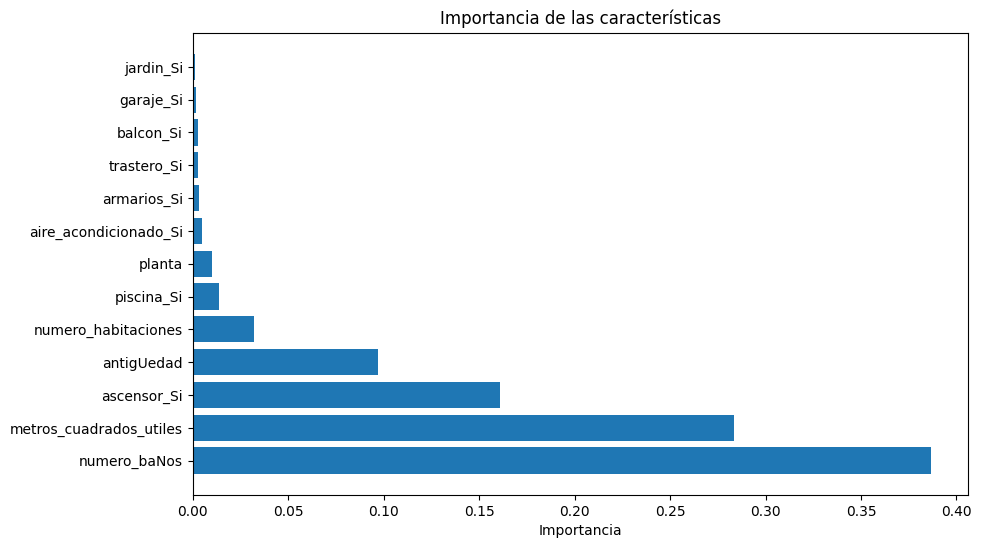

In [43]:
data_t = datos_sin_precio
data_l = datos_def['precio']

importances = best_tree.feature_importances_

# Crear un DataFrame para mostrar la importancia de cada característica
importance_df = pd.DataFrame({
    'Feature': data_t.columns,
    'Importance': importances
})

# Ordenar las características por importancia
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print(importance_df)


indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Importancia de las características")
plt.barh(range(len(indices)), importances[indices], align="center")
plt.yticks(range(len(indices)), [data_t.columns[i] for i in indices])
plt.xlabel("Importancia")
plt.show()

## **4  - Modelos Ensemble.**

## **Random Forest.**

In [44]:

# Importamos el módulo para aplicar Árboles de Decisión.
from sklearn.ensemble import RandomForestRegressor

# Modelo base
rf = RandomForestRegressor(
    random_state=99,
    n_jobs=-1
)

# Grid de hiperparámetros
param_grid_rf = {
    'n_estimators': [10, 20, 50, 75, 100, 200, 300],
    'max_depth': [8, 10, 12, None],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2']
}

# Validación cruzada
cv = KFold(n_splits=10, shuffle=True, random_state=99)

# GridSearch
grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=cv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

# IMPORTANTE: entrenar con log
grid_search_rf.fit(X_train, np.log(y_train))

best_rf = grid_search_rf.best_estimator_

y_pred_rf = np.exp(best_rf.predict(X_test))


#Obtenemos los valores del mejor modelo
print("Parametros mejor modelo: ", grid_search_rf.best_params_)


# MAE
mae_rf = mean_absolute_error(y_test, y_pred_rf)

# RMSE
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

# R2
r2_rf = r2_score(y_test, y_pred_rf)

# MAPE
mape_rf = np.mean(np.abs((y_test - y_pred_rf) / y_test)) * 100

# Mostrar resultados
print("Resultados Random Forest:")
print(f"MAE: {mae_rf:,.0f} €")
print(f"RMSE: {rmse_rf:,.0f} €")
print(f"R²: {r2_rf:.4f}")
print(f"MAPE: {mape_rf:.2f}%")

Parametros mejor modelo:  {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 300}
Resultados Random Forest:
MAE: 237,156 €
RMSE: 424,527 €
R²: 0.7609
MAPE: 32.76%


                    Feature  Importance
0   metros_cuadrados_utiles    0.297732
1              numero_baNos    0.216324
4                antigUedad    0.157382
6               ascensor_Si    0.078203
2       numero_habitaciones    0.074325
3                    planta    0.050969
5     aire_acondicionado_Si    0.038635
9                 garaje_Si    0.017012
7                piscina_Si    0.016536
12              armarios_Si    0.015104
11                jardin_Si    0.014915
8               trastero_Si    0.012172
10                balcon_Si    0.010692


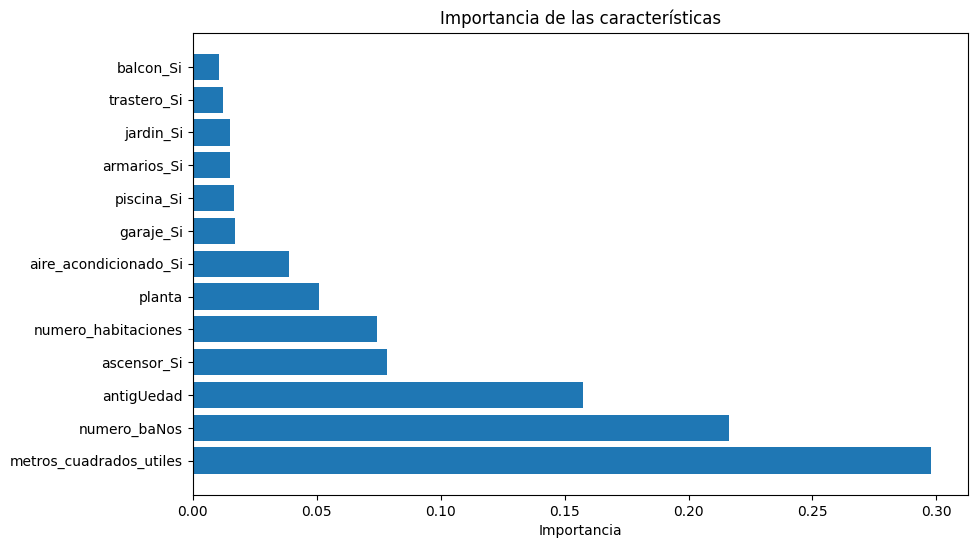

In [45]:
# Obtener la importancia de las características
importances = best_rf.feature_importances_

# Crear un DataFrame para mostrar la importancia de cada característica
importance_df = pd.DataFrame({
    'Feature': data_t.columns,
    'Importance': importances
})

# Ordenar las características por importancia
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print(importance_df)

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Importancia de las características")
plt.barh(range(len(indices)), importances[indices], align="center")
plt.yticks(range(len(indices)), [data_t.columns[i] for i in indices])
plt.xlabel("Importancia")
plt.show()

## **Bagging**

In [46]:
from sklearn.ensemble import BaggingRegressor


# Modelo base (árbol sencillo)
base_tree = DecisionTreeRegressor(random_state=99)

# Modelo Bagging
bagging = BaggingRegressor(
    estimator=base_tree,
    random_state=99,
    n_jobs=-1
)

# Grid de hiperparámetros
param_grid_bagging = {
    'n_estimators': [10, 25, 50, 100, 150, 200, 300],
    'max_samples': [0.6, 0.8, 1.0],
    'max_features': [0.6, 0.8, 1.0]
}

# Validación cruzada
cv = KFold(n_splits=10, shuffle=True, random_state=99)

# GridSearch
grid_search_bagging = GridSearchCV(
    estimator=bagging,
    param_grid=param_grid_bagging,
    cv=cv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

# Entrenamiento con log
grid_search_bagging.fit(X_train, np.log(y_train))


#MEJOR MODELO
best_bgg = grid_search_bagging.best_estimator_

y_pred_bgg = np.exp(best_bgg.predict(X_test))


#Obtenemos los valores del mejor modelo
print("Parametros mejor modelo: ", grid_search_bagging.best_params_)


# MAE
mae_bgg = mean_absolute_error(y_test, y_pred_bgg)

# RMSE
rmse_bgg = np.sqrt(mean_squared_error(y_test, y_pred_bgg))

# R2
r2_bgg = r2_score(y_test, y_pred_bgg)

# MAPE
mape_bgg = np.mean(np.abs((y_test - y_pred_bgg) / y_test)) * 100

# Mostrar resultados
print("Resultados Random Forest:")
print(f"MAE: {mae_bgg:,.0f} €")
print(f"RMSE: {rmse_bgg:,.0f} €")
print(f"R²: {r2_bgg:.4f}")
print(f"MAPE: {mape_bgg:.2f}%")

Parametros mejor modelo:  {'max_features': 1.0, 'max_samples': 0.6, 'n_estimators': 300}
Resultados Random Forest:
MAE: 234,709 €
RMSE: 414,180 €
R²: 0.7724
MAPE: 33.17%


## **Extra Trees**

In [47]:
from sklearn.ensemble import ExtraTreesRegressor

# Modelo base
et = ExtraTreesRegressor(random_state=99, n_jobs=-1)

# Espacio de hiperparámetros
param_grid_et = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2', 1.0]
}

# Validación cruzada
cv = KFold(n_splits=10, shuffle=True, random_state=99)

# GridSearch
grid_search_et = GridSearchCV(
    estimator=et,
    param_grid=param_grid_et,
    cv=cv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

# Entrenamiento con log del target
y_train_log = np.log(y_train)

grid_search_et.fit(X_train, y_train_log)

# Mejor modelo
best_et = grid_search_et.best_estimator_

# Predicción (deshaciendo log)
y_pred_et = np.exp(best_et.predict(X_test))

# Métricas
mae_et = mean_absolute_error(y_test, y_pred_et)
rmse_et = np.sqrt(mean_squared_error(y_test, y_pred_et))
r2_et = r2_score(y_test, y_pred_et)
mape_et = np.mean(np.abs((y_test - y_pred_et) / y_test)) * 100

# Resultados
print("Mejores parámetros:", grid_search_et.best_params_)
print("MAE:", mae_et)
print("RMSE:", rmse_et)
print("R2:", r2_et)
print("MAPE:", mape_et)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Mejores parámetros: {'max_depth': 20, 'max_features': 1.0, 'min_samples_leaf': 2, 'n_estimators': 300}
MAE: 235301.78874092796
RMSE: 420087.46755154827
R2: 0.7658421485262283
MAPE: 33.31942338842489


# Modelos Boost

### ADABOOST

In [48]:
from sklearn.ensemble import AdaBoostRegressor

# Modelo base
ada = AdaBoostRegressor(random_state=99)

# Grid de hiperparámetros
param_grid_ada = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0],
    'loss': ['linear', 'square', 'exponential']
}

# Validación cruzada
cv = KFold(n_splits=10, shuffle=True, random_state=99)

# GridSearch
grid_search_ada = GridSearchCV(
    estimator=ada,
    param_grid=param_grid_ada,
    cv=cv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

# Log del target
y_train_log = np.log(y_train)

# Entrenamiento
grid_search_ada.fit(X_train, y_train_log)

# Mejor modelo
best_ada = grid_search_ada.best_estimator_

# Predicción (invirtiendo log)
y_pred_ada = np.exp(best_ada.predict(X_test))

# Métricas
mae_ada = mean_absolute_error(y_test, y_pred_ada)
rmse_ada = np.sqrt(mean_squared_error(y_test, y_pred_ada))
r2_ada = r2_score(y_test, y_pred_ada)
mape_ada = np.mean(np.abs((y_test - y_pred_ada) / y_test)) * 100

# Resultados
print("Mejores parámetros:", grid_search_ada.best_params_)
print("MAE:", mae_ada)
print("RMSE:", rmse_ada)
print("R2:", r2_ada)
print("MAPE:", mape_ada)


Mejores parámetros: {'learning_rate': 0.1, 'loss': 'exponential', 'n_estimators': 100}
MAE: 318852.4141485365
RMSE: 566408.7913417337
R2: 0.5743141201938611
MAPE: 42.79337650571705


### GRADIENT BOOSTING

In [49]:
from sklearn.ensemble import GradientBoostingRegressor


# Modelo base
gbr = GradientBoostingRegressor(random_state=99)

# Grid de hiperparámetros
param_grid_gbr = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    'subsample': [0.6, 0.8, 1.0],
    'min_samples_leaf': [1, 2, 5]
}

# Validación cruzada
cv = KFold(n_splits=10, shuffle=True, random_state=99)

# GridSearch
grid_search_gbr = GridSearchCV(
    estimator=gbr,
    param_grid=param_grid_gbr,
    cv=cv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

# Log del target
y_train_log = np.log(y_train)

# Entrenamiento
grid_search_gbr.fit(X_train, y_train_log)

# Mejor modelo
best_gbr = grid_search_gbr.best_estimator_

# Predicción (invertir log)
y_pred_gbr = np.exp(best_gbr.predict(X_test))

# Métricas
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr = r2_score(y_test, y_pred_gbr)
mape_gbr = np.mean(np.abs((y_test - y_pred_gbr) / y_test)) * 100

# Resultados
print("Mejores parámetros:", grid_search_gbr.best_params_)
print("MAE:", mae_gbr)
print("RMSE:", rmse_gbr)
print("R2:", r2_gbr)
print("MAPE:", mape_gbr)

Mejores parámetros: {'learning_rate': 0.1, 'max_depth': 4, 'min_samples_leaf': 2, 'n_estimators': 300, 'subsample': 0.8}
MAE: 248030.48431412326
RMSE: 429600.19838056725
R2: 0.7551172350809867
MAPE: 34.45819407648148


### XGBOOST

In [50]:
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

# Modelo base
xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=99,
    n_jobs=-1
)

# Espacio de búsqueda (más amplio que grid)
param_dist_xgb = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6, 8],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5],
    'min_child_weight': [1, 3, 5]
}

# Validación cruzada
cv = KFold(n_splits=10, shuffle=True, random_state=99)

# Random Search
random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist_xgb,
    n_iter=50,  # número de combinaciones a probar
    cv=cv,
    scoring='neg_mean_absolute_error',
    random_state=99,
    n_jobs=-1
)

# Log del target
y_train_log = np.log(y_train)

# Entrenamiento
random_search_xgb.fit(X_train, y_train_log)

# Mejor modelo
best_xgb = random_search_xgb.best_estimator_

# Predicción (invertir log)
y_pred_xgb = np.exp(best_xgb.predict(X_test))

# Métricas
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)
mape_xgb = np.mean(np.abs((y_test - y_pred_xgb) / y_test)) * 100

# Resultados
print("Mejores parámetros:", random_search_xgb.best_params_)
print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2:", r2_xgb)
print("MAPE:", mape_xgb)

Mejores parámetros: {'subsample': 1.0, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.8}
MAE: 238099.5
RMSE: 416655.7490110991
R2: 0.7696521878242493
MAPE: 33.10845392931016


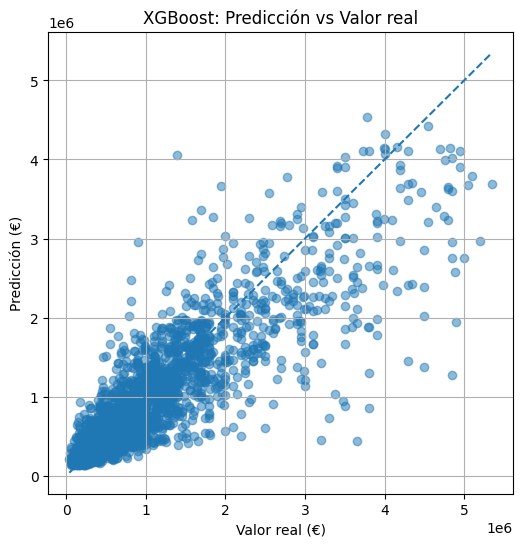

In [51]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_xgb, alpha=0.5)

# Línea ideal (predicción perfecta)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel("Valor real (€)")
plt.ylabel("Predicción (€)")
plt.title("XGBoost: Predicción vs Valor real")

plt.grid(True)
plt.show()

### LightGBM

In [52]:
from lightgbm import LGBMRegressor


# Modelo base
lgbm = LGBMRegressor(
    random_state=99,
    n_jobs=-1,
    verbose=-1
)

# Espacio de búsqueda
param_dist_lgbm = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [-1, 5, 10, 15],
    'num_leaves': [20, 31, 50, 70],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_samples': [10, 20, 30]
}

# Validación cruzada
cv = KFold(n_splits=10, shuffle=True, random_state=99)

# Random Search
random_search_lgbm = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist_lgbm,
    n_iter=50,
    cv=cv,
    scoring='neg_mean_absolute_error',
    random_state=99,
    n_jobs=-1
)

# Log del target
y_train_log = np.log(y_train)

# Entrenamiento
random_search_lgbm.fit(X_train, y_train_log)

# Mejor modelo
best_lgbm = random_search_lgbm.best_estimator_

# Predicción (invertir log)
y_pred_lgbm = np.exp(best_lgbm.predict(X_test))

# Métricas
mae_lgbm = mean_absolute_error(y_test, y_pred_lgbm)
rmse_lgbm = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))
r2_lgbm = r2_score(y_test, y_pred_lgbm)
mape_lgbm = np.mean(np.abs((y_test - y_pred_lgbm) / y_test)) * 100


# Resultados
print("Mejores parámetros:", random_search_lgbm.best_params_)
print("MAE:", mae_lgbm)
print("RMSE:", rmse_lgbm)
print("R2:", r2_lgbm)
print("MAPE:", mape_lgbm)

Mejores parámetros: {'subsample': 1.0, 'num_leaves': 50, 'n_estimators': 400, 'min_child_samples': 10, 'max_depth': -1, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
MAE: 239080.07740612747
RMSE: 416077.3629886149
R2: 0.7702912966786419
MAPE: 33.1276155624416


APLICAMOS STACKING

In [59]:
from sklearn.ensemble import StackingRegressor, BaggingRegressor
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


# Modelo base para Bagging
base_tree = DecisionTreeRegressor(random_state=99)

# Modelos base
estimators = [
    ('bagging', BaggingRegressor(
        estimator=base_tree,
        n_estimators=300,
        max_samples=0.6,
        max_features=1.0,
        random_state=99
    )),
    
    ('xgb', XGBRegressor(
        n_estimators=200,
        learning_rate=0.03,
        max_depth=8,
        subsample=1.0,
        colsample_bytree=0.8,
        min_child_weight=5,
        gamma=0,
        random_state=99
    )),
    
    ('lgbm', LGBMRegressor(
        n_estimators=400,
        learning_rate=0.05,
        num_leaves=50,
        max_depth=-1,
        subsample=1.0,
        colsample_bytree=0.8,
        min_child_samples=10,
        random_state=99,
        verbose=-1
    )),
    
    ('knn', KNeighborsRegressor(
        n_neighbors=15,
        weights='distance',
        p=1
    ))
]

# Meta-modelo
final_estimator = Ridge(alpha=1.0)

# Stacking
stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=final_estimator,
    cv=10,
    n_jobs=-1
)

#aplicamos LOG
y_train_log = np.log(y_train)

# Entrenar -> Necesario que X esté normalizado por el uso de KNN
stacking_model.fit(X_train_final, y_train_log)

# Predecir
y_pred_stack = stacking_model.predict(X_test_final)

#Deshacer LOG
y_pred = np.exp(y_pred_stack)


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MAE: {mae:,.0f} €")
print(f"RMSE: {rmse:,.0f} €")
print(f"R²: {r2:.3f}")
print(f"MAPE: {mape:.2f}%")

MAE: 233,936 €
RMSE: 409,370 €
R²: 0.778
MAPE: 32.55%
